In [12]:
from src.utils.simulation import load_ml_orchestration_params

analysis_metric = "projected_MSE"

benchmark_orchestration_params = load_ml_orchestration_params()
benchmark_settings = dict(benchmark_orchestration_params.get("benchmark", {}))
USE_OPTUNA = bool(benchmark_settings.get("use_optuna", False))

print(f"Classical benchmark Optuna enabled: {USE_OPTUNA}")
print(f"Analysis metric set to: {analysis_metric}")

Classical benchmark Optuna enabled: False
Analysis metric set to: projected_MSE


# Main Orchestration

This notebook runs the ASM2d-TCN simulation model from the source package and persists the generated dataset and metadata under the repository data contract.

In [13]:
import json

import numpy as np
import pandas as pd
from src.models.simulation.asm2d_tcn_simulation import get_asm2d_tcn_matrices, load_asm2d_tcn_simulation_params
from src.utils.simulation import get_repo_root

repo_root = get_repo_root()
simulation_dir = repo_root / "data" / "asm2d-tcn" / "simulation"

dataset_candidates = {
    path.stem.removeprefix("data_"): path
    for path in simulation_dir.glob("data_*.csv")
    }
metadata_candidates = {
    path.stem.removeprefix("metadata_"): path
    for path in simulation_dir.glob("metadata_*.json")
    }

if not dataset_candidates:
    raise FileNotFoundError(f"No ASM2d-TCN datasets found in {simulation_dir}")
if not metadata_candidates:
    raise FileNotFoundError(f"No ASM2d-TCN metadata files found in {simulation_dir}")

shared_timestamps = sorted(set(dataset_candidates) & set(metadata_candidates))
if shared_timestamps:
    latest_timestamp = shared_timestamps[-1]
    latest_dataset_path = dataset_candidates[latest_timestamp]
    latest_metadata_path = metadata_candidates[latest_timestamp]
else:
    latest_dataset_path = max(dataset_candidates.values(), key=lambda path: path.stat().st_mtime)
    latest_metadata_path = max(metadata_candidates.values(), key=lambda path: path.stat().st_mtime)

dataset = pd.read_csv(latest_dataset_path)
metadata = json.loads(latest_metadata_path.read_text(encoding="utf-8"))
artifact_paths = {
    "dataset_csv": latest_dataset_path,
    "metadata_json": latest_metadata_path,
    }

workbook_path = repo_root / "data" / "asm2d-tcn" / "asm2d_tcn_workbook.xlsx"
if not workbook_path.exists():
    raise FileNotFoundError(f"ASM2d-TCN workbook not found: {workbook_path}")

state_columns = list(metadata["state_columns"])
measured_output_columns = list(metadata["measured_output_columns"])

stoichiometric_frame = pd.read_excel(
    workbook_path,
    sheet_name="stoichiometric_matrix",
    engine="openpyxl",
    )
composition_frame = pd.read_excel(
    workbook_path,
    sheet_name="composition_matrix",
    engine="openpyxl",
    )

petersen_matrix = stoichiometric_frame.loc[:, state_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
composition_by_state = (
    composition_frame.loc[:, ["state_variable", *measured_output_columns]]
    .set_index("state_variable")
    .reindex(state_columns)
    )
composition_matrix = (
    composition_by_state.loc[:, measured_output_columns]
    .T
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
    )

matrix_source = str(workbook_path.relative_to(repo_root))
if np.isnan(petersen_matrix).any() or np.isnan(composition_matrix).any():
    matrix_bundle = get_asm2d_tcn_matrices(load_asm2d_tcn_simulation_params(repo_root))
    petersen_matrix = matrix_bundle["petersen_matrix"]
    composition_matrix = matrix_bundle["composition_matrix"]
    matrix_source = "runtime matrix bundle (workbook formulas unresolved)"

print(f"Loaded {len(dataset)} rows for {metadata['simulation_name']}.")
print(f"Dataset loaded from: {artifact_paths['dataset_csv']}")
print(f"Metadata loaded from: {artifact_paths['metadata_json']}")
print(f"Matrix source: {matrix_source}")
print(f"Petersen matrix shape: {petersen_matrix.shape}")
print(f"Composition matrix shape: {composition_matrix.shape}")

display(dataset.head())
display(pd.Series(metadata, name="value").to_frame())
display(pd.DataFrame(petersen_matrix, index=metadata["processes"], columns=state_columns))
display(pd.DataFrame(composition_matrix, index=measured_output_columns, columns=state_columns))

Loaded 10000 rows for asm2d_tcn_simulation.
Dataset loaded from: C:\Users\eselerio\projects\pibre-model\data\asm2d-tcn\simulation\data_20260330_024847.csv
Metadata loaded from: C:\Users\eselerio\projects\pibre-model\data\asm2d-tcn\simulation\metadata_20260330_024847.json
Matrix source: runtime matrix bundle (workbook formulas unresolved)
Petersen matrix shape: (28, 21)
Composition matrix shape: (6, 21)


,HRT,Aeration,In_S_A,In_S_F,In_S_I,In_S_N2,In_S_NH4,In_S_NO2,In_S_NO3,In_S_PO4,...,In_X_NOB,In_X_TSS,In_X_MeOH,In_X_MeP,Out_COD,Out_TN,Out_TKN,Out_TP,Out_TSS,Out_VSS
0,16.635779,2.441396,63.046704,90.220550,78.687834,1.394736,16.049626,2.926867,6.089118,14.577029,...,0.978629,388.410985,7.579973,9.097053,555.678020,50.365710,32.658337,33.044827,422.541437,356.848357
1,30.967794,2.109529,71.984084,144.541360,25.571097,0.933442,13.883562,0.462868,5.464392,13.916194,...,3.778639,255.493219,8.403181,3.748400,343.718748,36.592386,22.913018,29.943624,280.266159,237.875882
2,15.118503,0.561636,34.060878,66.132497,64.599640,0.279505,20.596053,0.022087,6.295395,12.637614,...,6.237491,292.601437,6.642953,6.710486,397.941176,37.115558,35.183335,32.196433,295.605893,242.432755
3,10.569363,1.892641,37.753804,54.333548,42.682291,1.706806,22.059398,0.174908,2.251071,6.697500,...,5.917695,333.320188,1.935261,6.012537,467.332598,45.903546,41.089729,18.652202,350.851130,317.162135
4,23.376587,0.853546,38.461721,80.963396,34.120967,1.260565,27.557942,0.262950,0.944047,17.390363,...,7.269518,384.463498,2.428360,3.671479,452.266376,53.187988,53.081237,34.920484,344.147692,310.844596


,value
simulation_name,asm2d_tcn_simulation
n_samples,10000
random_seed,42
dependent_columns,"[Out_COD, Out_TN, Out_TKN, Out_TP, Out_TSS, Ou..."
independent_columns,"[HRT, Aeration, In_S_A, In_S_F, In_S_I, In_S_N..."
identifier_columns,[]
ignored_columns,[]
dataset_file,data/asm2d-tcn/simulation/data_20260330_024847...
state_columns,"[S_A, S_F, S_I, S_N2, S_NH4, S_NO2, S_NO3, S_P..."
measured_output_columns,"[COD, TN, TKN, TP, TSS, VSS]"


,S_A,S_F,S_I,S_N2,S_NH4,S_NO2,S_NO3,S_PO4,S_ALK,S_O2,...,X_S,X_H,X_PAO,X_PP,X_PHA,X_AOB,X_NOB,X_TSS,X_MeOH,X_MeP
Aerobic hydrolysis,0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Anoxic hydrolysis (NO2),0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Anoxic hydrolysis (NO3),0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Anaerobic hydrolysis,0.0,1.0,0.0,0.000000,0.010000,0.000000,0.000000,-0.0000,0.000714,0.000000,...,-1.0,0.0,0.000,0.0,0.0,0.0,0.0,-0.75000,0.00,0.00
Aerobic growth on S_F,0.0,-1.6,0.0,0.000000,-0.038000,0.000000,0.000000,-0.0040,-0.002843,-0.600000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Aerobic growth on S_A,-1.6,0.0,0.0,0.000000,-0.086000,0.000000,0.000000,-0.0200,-0.006788,-0.600000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_F (NO3 -> NO2),0.0,-1.6,0.0,0.000000,-0.038000,0.525000,-0.525000,-0.0040,-0.002843,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_F (NO2 -> N2),0.0,-1.6,0.0,0.348837,-0.038000,-0.348837,0.000000,-0.0040,0.022074,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_A (NO3 -> NO2),-1.6,0.0,0.0,0.000000,-0.086000,0.525000,-0.525000,-0.0200,-0.006788,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00
Anoxic growth on S_A (NO2 -> N2),-1.6,0.0,0.0,0.348837,-0.086000,-0.348837,0.000000,-0.0200,0.018129,0.000000,...,0.0,1.0,0.000,0.0,0.0,0.0,0.0,0.75000,0.00,0.00


,S_A,S_F,S_I,S_N2,S_NH4,S_NO2,S_NO3,S_PO4,S_ALK,S_O2,...,X_S,X_H,X_PAO,X_PP,X_PHA,X_AOB,X_NOB,X_TSS,X_MeOH,X_MeP
COD,1.0,1.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.00,1.000,1.000,0.0,1.00,1.000,1.000,0.0,0.0,0.000
TN,0.0,0.03,0.01,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.04,0.086,0.086,0.0,0.00,0.086,0.086,0.0,0.0,0.000
TKN,0.0,0.03,0.01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.04,0.086,0.086,0.0,0.00,0.086,0.086,0.0,0.0,0.000
TP,0.0,0.01,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.01,0.020,0.020,1.0,0.00,0.020,0.020,0.0,0.0,0.205
TSS,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.000,0.000,0.0,0.00,0.000,0.000,1.0,0.0,0.000
VSS,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.75,0.750,0.750,0.0,0.75,0.750,0.750,0.0,0.0,0.000


In [14]:
import numpy as np
import pandas as pd
from scipy.linalg import null_space

from src.utils.process import has_active_projection

cobre_constraint_basis = null_space(petersen_matrix)
cobre_A_matrix = cobre_constraint_basis.T

cobre_A_matrix = np.round(cobre_A_matrix, 5)
cobre_A_matrix[np.abs(cobre_A_matrix) < 1e-10] = 0.0

for row_index in range(cobre_A_matrix.shape[0]):
    non_zero_entries = cobre_A_matrix[row_index, cobre_A_matrix[row_index, :] != 0]
    if len(non_zero_entries) > 0:
        cobre_A_matrix[row_index, :] = cobre_A_matrix[row_index, :] / non_zero_entries[0]

macroscopic_stoichiometric_matrix = petersen_matrix @ composition_matrix.T
measured_constraint_basis = null_space(macroscopic_stoichiometric_matrix)
A_matrix = measured_constraint_basis.T

A_matrix = np.round(A_matrix, 5)
A_matrix[np.abs(A_matrix) < 1e-10] = 0.0

for row_index in range(A_matrix.shape[0]):
    non_zero_entries = A_matrix[row_index, A_matrix[row_index, :] != 0]
    if len(non_zero_entries) > 0:
        A_matrix[row_index, :] = A_matrix[row_index, :] / non_zero_entries[0]

classical_projection_active = has_active_projection(A_matrix)
measured_output_dimension = int(A_matrix.shape[1])
measured_nullity = int(A_matrix.shape[0])
macroscopic_rank = int(np.linalg.matrix_rank(macroscopic_stoichiometric_matrix))
classical_projection_status = pd.DataFrame(
    [
        {
            "projection_active": classical_projection_active,
            "constraint_status": "active" if classical_projection_active else "inactive_trivial_null_space",
            "measured_output_dimension": measured_output_dimension,
            "rank_S_macro": macroscopic_rank,
            "nullity_S_macro": measured_nullity,
        }
    ]
)

print(f"Fractional Petersen matrix shape: {petersen_matrix.shape}")
print(f"COBRE invariant matrix shape: {cobre_A_matrix.shape}")
print(f"Measured-space invariant matrix shape kept for downstream regressors: {A_matrix.shape}")
if classical_projection_active:
    print("Classical measured-space projection remains active because the measured-output null space is non-trivial.")
else:
    print("Classical measured-space projection is inactive because null_space(nu I_comp^T) is trivial in the measured-output basis.")
    print("Projected classical results and measured-space mass-balance discrepancy tables are suppressed downstream.")

display(
    pd.DataFrame(
        cobre_A_matrix,
        index=[f"constraint_{index + 1}" for index in range(cobre_A_matrix.shape[0])],
        columns=metadata["state_columns"],
    )
)
display(
    pd.DataFrame(
        A_matrix,
        index=[f"constraint_{index + 1}" for index in range(A_matrix.shape[0])],
        columns=metadata["measured_output_columns"],
    )
)
display(classical_projection_status)

Fractional Petersen matrix shape: (28, 21)
COBRE invariant matrix shape: (6, 21)
Measured-space invariant matrix shape kept for downstream regressors: (0, 6)
Classical measured-space projection is inactive because null_space(nu I_comp^T) is trivial in the measured-output basis.
Projected classical results and measured-space mass-balance discrepancy tables are suppressed downstream.


,S_A,S_F,S_I,S_N2,S_NH4,S_NO2,S_NO3,S_PO4,S_ALK,S_O2,...,X_S,X_H,X_PAO,X_PP,X_PHA,X_AOB,X_NOB,X_TSS,X_MeOH,X_MeP
constraint_1,-0.0,1.0,-122.115741,43.285494,43.180556,43.391975,43.391975,-29.893519,1.476852,-0.0,...,6.891975,8.584877,8.584877,-6.334877,4.367284,8.584877,8.584877,-7.279321,2.435185,-2.280864
constraint_2,0.0,1.0,41.259080,30.538741,30.934625,30.142857,30.142857,8.578692,-5.548426,0.0,...,-1.389831,0.099274,0.099274,-3.207022,-2.156174,0.099274,0.099274,3.593220,77.556901,55.619855
constraint_3,0.0,1.0,-17.963673,7.606458,9.781029,5.431887,5.431887,78.202825,-30.441978,0.0,...,-17.095863,-15.973764,-15.973764,-1.039354,-14.537841,-15.973764,-15.973764,24.229062,-13.890010,-1.048436
constraint_4,0.0,1.0,50.768730,34.358306,33.546145,35.171553,35.171553,-3.445168,11.373507,0.0,...,1.364821,2.915309,2.915309,-2.984799,0.017372,2.915309,2.915309,-0.029316,-52.864278,-38.073833
constraint_5,-0.0,1.0,0.197026,7.572491,11.695167,3.449814,3.449814,79.107807,-57.717472,-0.0,...,56.650558,57.769517,57.769517,316.583643,44.460967,57.769517,57.769517,-74.100372,-20.063197,23.252788
constraint_6,-0.0,1.0,-31.996269,-6.250000,-30.932836,18.432836,18.432836,107.679104,345.544776,-0.0,...,-13.630597,-12.731343,-12.731343,56.078358,-11.656716,-12.731343,-12.731343,19.425373,11.552239,26.917910


,COD,TN,TKN,TP,TSS,VSS


,projection_active,constraint_status,measured_output_dimension,rank_S_macro,nullity_S_macro
0,False,inactive_trivial_null_space,6,6,0


In [15]:
import pandas as pd

from src.utils.analysis import describe_and_display_table
from src.utils.process import (
    apply_train_test_split_indices,
    build_cobre_supervised_dataset,
    build_fractional_input_measured_output_dataset,
    make_train_test_split_indices,
    sample_dataset_split_indices,
    select_dataset_rows,
    )
from src.utils.simulation import load_ml_orchestration_params

ml_orchestration_params = load_ml_orchestration_params()
ml_orchestration = dict(ml_orchestration_params["hyperparameters"])
benchmark_settings = dict(ml_orchestration_params.get("benchmark", {}))
USE_OPTUNA = bool(benchmark_settings.get("use_optuna", False))

classical_benchmark_dataset = build_fractional_input_measured_output_dataset(
    dataset,
    metadata,
    composition_matrix,
    )
cobre_dataset = build_cobre_supervised_dataset(
    dataset,
    metadata,
    composition_matrix,
    )

shared_split_indices = make_train_test_split_indices(
    dataset.index,
    test_fraction=float(ml_orchestration["test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
    )
main_dataset_splits = apply_train_test_split_indices(
    classical_benchmark_dataset,
    shared_split_indices,
    )
cobre_dataset_splits = apply_train_test_split_indices(
    cobre_dataset,
    shared_split_indices,
    )

optuna_indices = sample_dataset_split_indices(
    shared_split_indices.train,
    fraction=float(ml_orchestration["optuna_dataset_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
    )
optuna_dataset = select_dataset_rows(
    classical_benchmark_dataset,
    optuna_indices,
    )
tuning_split_indices = make_train_test_split_indices(
    optuna_indices,
    test_fraction=float(ml_orchestration["optuna_test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
    )
tuning_dataset_splits = apply_train_test_split_indices(
    classical_benchmark_dataset,
    tuning_split_indices,
    )

split_sizes = {
    "train": len(main_dataset_splits.train.features),
    "test": len(main_dataset_splits.test.features),
    "optuna_dataset": len(optuna_dataset.features),
    "optuna_train": len(tuning_dataset_splits.train.features),
    "optuna_test": len(tuning_dataset_splits.test.features),
    }
classical_split_sizes = {
    "train": len(main_dataset_splits.train.features),
    "test": len(main_dataset_splits.test.features),
    "fractional_input_features": len(classical_benchmark_dataset.features.columns),
    "measured_targets": len(classical_benchmark_dataset.targets.columns),
    "measured_constraints": len(classical_benchmark_dataset.constraint_reference.columns),
    }
cobre_split_sizes = {
    "train": len(cobre_dataset_splits.train.features),
    "test": len(cobre_dataset_splits.test.features),
    "fractional_features": len(cobre_dataset.features.columns),
    "measured_targets": len(cobre_dataset.targets.columns),
    "fractional_constraints": len(cobre_dataset.constraint_reference.columns),
    }
split_alignment_ok = (
    main_dataset_splits.train.features.index.equals(cobre_dataset_splits.train.features.index)
    and main_dataset_splits.test.features.index.equals(cobre_dataset_splits.test.features.index)
    )
feature_alignment_ok = (
    main_dataset_splits.train.features.columns.equals(cobre_dataset_splits.train.features.columns)
    and main_dataset_splits.test.features.columns.equals(cobre_dataset_splits.test.features.columns)
    )
target_alignment_ok = (
    main_dataset_splits.train.targets.columns.equals(cobre_dataset_splits.train.targets.columns)
    and main_dataset_splits.test.targets.columns.equals(cobre_dataset_splits.test.targets.columns)
    )
optuna_subset_ok = set(shared_split_indices.test).isdisjoint(optuna_indices)

benchmark_contract_summary = pd.DataFrame(
    [
        {
            "classical_feature_space": "operational_plus_fractional_influent",
            "cobre_feature_space": "operational_plus_fractional_influent",
            "shared_target_space": "measured_outputs",
            "shared_split_indices": split_alignment_ok,
            "shared_feature_columns": feature_alignment_ok,
            "shared_target_columns": target_alignment_ok,
            "optuna_subset_from_training_pool_only": optuna_subset_ok,
            "classical_optuna_enabled": USE_OPTUNA,
            }
        ]
    )

print("Notebook-managed ML orchestration is ready.")
print(
    "Classical and COBRE now share the same operational-plus-fractional input basis for the benchmark path."
    )
print(f"Shared split indices aligned across COBRE and the classical benchmark: {split_alignment_ok}")
print(f"Shared feature columns aligned across COBRE and the classical benchmark: {feature_alignment_ok}")
print(f"Shared target columns aligned across COBRE and the classical benchmark: {target_alignment_ok}")
print(f"Optuna subset drawn only from the shared training pool: {optuna_subset_ok}")

describe_and_display_table(
    "ML orchestration settings",
    "This table shows the shared orchestration hyperparameters and benchmark toggles that control the train-test split, the optional Optuna subset, and whether tuned classical runs are enabled.",
    pd.DataFrame([{**ml_orchestration, **benchmark_settings}]),
    )
describe_and_display_table(
    "Classical benchmark split summary",
    "This table summarizes the split sizes and dataset dimensions used by the classical benchmark models after aligning their inputs and targets with COBRE.",
    pd.DataFrame([classical_split_sizes]),
    )
describe_and_display_table(
    "COBRE split summary",
    "This table summarizes the split sizes and dataset dimensions used by COBRE under the same authoritative train-test row split.",
    pd.DataFrame([cobre_split_sizes]),
    )
describe_and_display_table(
    "Benchmark contract checks",
    "This table confirms whether COBRE and the classical benchmark share the same row splits, the same feature columns, the same measured targets, and an Optuna subset restricted to the shared training pool.",
    benchmark_contract_summary,
    )

Notebook-managed ML orchestration is ready.
Classical and COBRE now share the same operational-plus-fractional input basis for the benchmark path.
Shared split indices aligned across COBRE and the classical benchmark: True
Shared feature columns aligned across COBRE and the classical benchmark: True
Shared target columns aligned across COBRE and the classical benchmark: True
Optuna subset drawn only from the shared training pool: True
ML orchestration settings
This table shows the shared orchestration hyperparameters and benchmark toggles that control the train-test split, the optional Optuna subset, and whether tuned classical runs are enabled.


,random_seed,test_fraction,optuna_dataset_fraction,optuna_test_fraction,tuning_epochs,n_trials,timeout_seconds,use_optuna
0,42,0.2,0.5,0.2,500,30,None,False


Classical benchmark split summary
This table summarizes the split sizes and dataset dimensions used by the classical benchmark models after aligning their inputs and targets with COBRE.


,train,test,fractional_input_features,measured_targets,measured_constraints
0,8000,2000,23,6,6


COBRE split summary
This table summarizes the split sizes and dataset dimensions used by COBRE under the same authoritative train-test row split.


,train,test,fractional_features,measured_targets,fractional_constraints
0,8000,2000,23,6,21


Benchmark contract checks
This table confirms whether COBRE and the classical benchmark share the same row splits, the same feature columns, the same measured targets, and an Optuna subset restricted to the shared training pool.


,classical_feature_space,cobre_feature_space,shared_target_space,shared_split_indices,shared_feature_columns,shared_target_columns,optuna_subset_from_training_pool_only,classical_optuna_enabled
0,operational_plus_fractional_influent,operational_plus_fractional_influent,measured_outputs,True,True,True,True,False


,classical_feature_space,cobre_feature_space,shared_target_space,shared_split_indices,shared_feature_columns,shared_target_columns,optuna_subset_from_training_pool_only,classical_optuna_enabled
0,operational_plus_fractional_influent,operational_plus_fractional_influent,measured_outputs,True,True,True,True,False


## COBRE

This section now follows the strict fractional-space COBRE formulation. The notebook passes operational variables and influent ASM1 fractions into the bilinear model, derives the invariant matrix from the Petersen null space, and collapses the projected fractional prediction into the measured composite space with the composition matrix.

COBRE still uses a closed-form projected OLS solve with `ols_backend="numpy_lstsq"`, so there is no Optuna tuning branch for this model.

In [16]:
import pandas as pd

from src.models.ml import load_cobre_params, run_cobre_pipeline
from src.utils.analysis import describe_and_display_table

cobre_params = load_cobre_params()
cobre_hyperparameters = dict(cobre_params["training_defaults"])

cobre_result = run_cobre_pipeline(
    cobre_dataset_splits.train,
    cobre_dataset_splits.test,
    cobre_A_matrix,
    composition_matrix=composition_matrix,
    model_params=cobre_params,
    model_hyperparameters=cobre_hyperparameters,
    persist_artifacts=True,
    )
cobre_coefficient_inference = dict(cobre_result["coefficient_inference"])
cobre_coefficient_inference_metadata = pd.DataFrame(
    [
        {
            "method": cobre_coefficient_inference["method"],
            "confidence_level": cobre_coefficient_inference["confidence_level"],
            "coefficient_target": cobre_coefficient_inference["coefficient_target"],
            "rank_deficient": cobre_coefficient_inference["rank_deficient"],
            "design_rank": cobre_coefficient_inference["design_rank"],
            "design_dimension": cobre_coefficient_inference["design_dimension"],
            "degrees_of_freedom": cobre_coefficient_inference["degrees_of_freedom"],
            "note": cobre_coefficient_inference.get("note"),
        }
    ]
)

print("COBRE training complete.")
print(f"Operational inputs: {', '.join(metadata['operational_columns'])}")
print(f"Fractional influent states: {', '.join(metadata['state_columns'])}")
print(f"Measured-output targets: {', '.join(metadata['measured_output_columns'])}")
print(f"COBRE split sizes: {cobre_split_sizes}")
print(f"Saved model bundle: {cobre_result['artifact_paths']['model_bundle']}")
print(f"Saved metrics summary: {cobre_result['artifact_paths']['metrics']}")

describe_and_display_table(
    "COBRE report metadata",
    "This table explains the COBRE reporting contract. Measured-output metrics are the direct comparison layer, while the fractional-space diagnostics remain COBRE-native diagnostics.",
    cobre_result["test_report"]["report_metadata"],
    )
describe_and_display_table(
    "COBRE hyperparameters",
    "This table lists the hyperparameters used to fit the COBRE model in the current run.",
    pd.DataFrame([cobre_result["best_hyperparameters"]]),
    )
describe_and_display_table(
    "COBRE coefficient inference metadata",
    "This table records how coefficient uncertainty was estimated for the identifiable measured-space operator M and whether the COBRE design was rank deficient.",
    cobre_coefficient_inference_metadata,
    )
describe_and_display_table(
    "COBRE split summary",
    "This table summarizes the training and testing split sizes and the dimensionality of the COBRE dataset used in this run.",
    pd.DataFrame([cobre_split_sizes]),
    )
describe_and_display_table(
    "COBRE artifact paths",
    "This table lists the artifact paths produced by the COBRE run, including the saved model bundle and metric summary.",
    pd.Series(cobre_result["artifact_paths"], name="path").to_frame(),
    )
describe_and_display_table(
    "COBRE collapse operator",
    "This table shows the collapse operator G = I_comp P_adm that maps the identifiable measured-space operator onto projected measured outputs.",
    pd.DataFrame(
        cobre_result["model_bundle"]["collapse_operator"],
        index=metadata["measured_output_columns"],
        columns=metadata["state_columns"],
        ),
    )
describe_and_display_table(
    "COBRE pass-through operator",
    "This table shows the invariant carry-through operator H = I_comp P_inv that propagates the conserved influent contribution from fractional space into measured-output space.",
    pd.DataFrame(
        cobre_result["model_bundle"]["pass_through_operator"],
        index=metadata["measured_output_columns"],
        columns=metadata["state_columns"],
        ),
    )
describe_and_display_table(
    "COBRE train aggregate metrics",
    "This table reports the train-split measured-output metrics for COBRE. These aggregate values are directly comparable with the classical benchmark models.",
    cobre_result["train_report"]["aggregate_metrics"],
    )
describe_and_display_table(
    "COBRE test aggregate metrics",
    "This table reports the test-split measured-output metrics for COBRE. These aggregate values are directly comparable with the classical benchmark models.",
    cobre_result["test_report"]["aggregate_metrics"],
    )
describe_and_display_table(
    "COBRE test per-target metrics",
    "This table breaks down the COBRE test metrics by measured-output target so each effluent variable can be compared separately.",
    cobre_result["test_report"]["per_target_metrics"],
    )
describe_and_display_table(
    "COBRE test prediction uncertainty summary",
    "This table summarizes the average widths and standard errors of the COBRE projected measured-output confidence and prediction intervals on the test split.",
    cobre_result["test_report"]["prediction_uncertainty_summary"],
    )
describe_and_display_table(
    "COBRE test diagnostic summary",
    "This table summarizes COBRE-native diagnostics, including fractional constraint residuals and raw-to-projected adjustment magnitudes. These diagnostics complement the direct comparison metrics but are not themselves apples-to-apples rankings against the classical models.",
    cobre_result["test_report"]["diagnostic_summary"],
    )
describe_and_display_table(
    "COBRE test constraint residual summary",
    "This table summarizes the sample-level fractional constraint residual norms on the COBRE test split.",
    cobre_result["test_report"]["constraint_residuals"].describe().T,
    )

COBRE training complete.
Operational inputs: HRT, Aeration
Fractional influent states: S_A, S_F, S_I, S_N2, S_NH4, S_NO2, S_NO3, S_PO4, S_ALK, S_O2, X_I, X_S, X_H, X_PAO, X_PP, X_PHA, X_AOB, X_NOB, X_TSS, X_MeOH, X_MeP
Measured-output targets: COD, TN, TKN, TP, TSS, VSS
COBRE split sizes: {'train': 8000, 'test': 2000, 'fractional_features': 23, 'measured_targets': 6, 'fractional_constraints': 21}
Saved model bundle: C:\Users\eselerio\projects\pibre-model\results\cobre\model_20260401_165449.pkl
Saved metrics summary: C:\Users\eselerio\projects\pibre-model\results\cobre\metrics_20260401_165449.json
COBRE report metadata
This table explains the COBRE reporting contract. Measured-output metrics are the direct comparison layer, while the fractional-space diagnostics remain COBRE-native diagnostics.


,native_prediction_space,comparison_target_space,constraint_space,direct_comparison_scope,diagnostic_scope,projection_active,constraint_status
0,fractional,measured,fractional,measured_output_metrics_only,model_native_fractional_space_diagnostics,True,active


COBRE hyperparameters
This table lists the hyperparameters used to fit the COBRE model in the current run.


,objective,solver,ols_backend,include_bias_term,lstsq_rcond,uncertainty_method,confidence_level,bootstrap_samples,bootstrap_random_seed
0,projected_ols,multivariate_lstsq,numpy_lstsq,True,None,analytic,0.95,20,42


COBRE coefficient inference metadata
This table records how coefficient uncertainty was estimated for the identifiable measured-space operator M and whether the COBRE design was rank deficient.


...

COBRE test diagnostic summary
This table summarizes COBRE-native diagnostics, including fractional constraint residuals and raw-to-projected adjustment magnitudes. These diagnostics complement the direct comparison metrics but are not themselves apples-to-apples rankings against the classical models.


,diagnostic_name,prediction_type,constraint_mean_l2,constraint_max_l2,constraint_mean_abs,constraint_max_abs,mean_l2,max_l2,mean_abs,max_abs
0,fractional_constraint_residual,raw,5.991861e+04,9.374183e+04,1.396117e+04,9.256500e+04,NaN,NaN,NaN,NaN
1,fractional_constraint_residual,projected,4.842017e-11,1.218969e-10,1.412114e-11,1.164153e-10,NaN,NaN,NaN,NaN
2,measured_projection_adjustment,raw_to_projected,NaN,NaN,NaN,NaN,68.250790,100.977191,22.371001,74.002028
3,fractional_projection_adjustment,raw_to_projected,NaN,NaN,NaN,NaN,178.398731,271.674230,16.711768,255.214248


COBRE test constraint residual summary
This table summarizes the sample-level fractional constraint residual norms on the COBRE test split.


,count,mean,std,min,25%,50%,75%,max
raw_constraint_l2,2000.0,5.991861e+04,1.822054e+04,2.889689e+04,4.371697e+04,5.940236e+04,7.573065e+04,9.374183e+04
projected_constraint_l2,2000.0,4.842017e-11,1.936333e-11,1.064536e-11,3.340962e-11,4.448628e-11,5.912546e-11,1.218969e-10


,count,mean,std,min,25%,50%,75%,max
raw_constraint_l2,2000.0,5.991861e+04,1.822054e+04,2.889689e+04,4.371697e+04,5.940236e+04,7.573065e+04,9.374183e+04
projected_constraint_l2,2000.0,4.842017e-11,1.936333e-11,1.064536e-11,3.340962e-11,4.448628e-11,5.912546e-11,1.218969e-10


In [17]:
from src.utils.analysis import build_negative_prediction_tables, describe_and_display_table

cobre_negative_prediction_tables = build_negative_prediction_tables(
    {
        "train": cobre_result["train_report"],
        "test": cobre_result["test_report"],
    }
)
cobre_negative_prediction_summary = cobre_negative_prediction_tables["summary"]
cobre_negative_prediction_per_target = cobre_negative_prediction_tables["per_target"]

projected_test_negative_summary = cobre_negative_prediction_summary.loc[
    (cobre_negative_prediction_summary["split"] == "test")
    & (cobre_negative_prediction_summary["prediction_type"] == "projected")
].iloc[0]

print(
    "Projected COBRE test predictions are negative in "
    f"{int(projected_test_negative_summary['negative_predictions'])} of "
    f"{int(projected_test_negative_summary['total_predictions'])} predicted target values "
    f"({projected_test_negative_summary['negative_prediction_rate_pct']:.2f}%)."
)
print(
    "Those negatives occur in "
    f"{int(projected_test_negative_summary['samples_with_any_negative'])} of "
    f"{int(projected_test_negative_summary['total_samples'])} test samples "
    f"({projected_test_negative_summary['sample_incidence_rate_pct']:.2f}%)."
)
print(
    "The most negative projected test prediction is "
    f"{projected_test_negative_summary['minimum_prediction']:.6f}."
)

describe_and_display_table(
    "COBRE negative prediction incidence summary",
    "This table summarizes how often COBRE produces negative measured-output predictions on the train and test splits, comparing the raw measured predictions with the projected measured predictions after enforcing the COBRE constraints.",
    cobre_negative_prediction_summary,
    )
describe_and_display_table(
    "COBRE negative prediction incidence by target",
    "This table breaks down the negative-prediction incidence by measured-output target for COBRE, including counts, rates, and the observed magnitude of the negative predictions for both raw and projected outputs.",
    cobre_negative_prediction_per_target,
    )

Projected COBRE test predictions are negative in 0 of 12000 predicted target values (0.00%).
Those negatives occur in 0 of 2000 test samples (0.00%).
The most negative projected test prediction is 3.576515.
COBRE negative prediction incidence summary
This table summarizes how often COBRE produces negative measured-output predictions on the train and test splits, comparing the raw measured predictions with the projected measured predictions after enforcing the COBRE constraints.


,split,prediction_type,total_predictions,negative_predictions,negative_prediction_rate_pct,total_samples,samples_with_any_negative,sample_incidence_rate_pct,avg_negative_targets_per_affected_sample,minimum_prediction,mean_negative_prediction,median_negative_prediction
0,train,raw,48000,3937,8.202083,8000,3904,48.8,1.008453,-4.679642,-0.073198,-0.051149
1,train,projected,48000,0,0.000000,8000,0,0.0,0.000000,4.027967,NaN,NaN
2,test,raw,12000,985,8.208333,2000,974,48.7,1.011294,-3.571500,-0.083693,-0.056699
3,test,projected,12000,0,0.000000,2000,0,0.0,0.000000,3.576515,NaN,NaN


COBRE negative prediction incidence by target
This table breaks down the negative-prediction incidence by measured-output target for COBRE, including counts, rates, and the observed magnitude of the negative predictions for both raw and projected outputs.


,split,prediction_type,target,negative_predictions,negative_prediction_rate_pct,minimum_prediction,mean_negative_prediction,median_negative_prediction
0,test,projected,Out_TKN,0,0.0000,3.576515,NaN,NaN
1,test,projected,Out_TP,0,0.0000,9.474292,NaN,NaN
2,test,projected,Out_TN,0,0.0000,27.675672,NaN,NaN
3,test,projected,Out_VSS,0,0.0000,120.514530,NaN,NaN
4,test,projected,Out_TSS,0,0.0000,152.931913,NaN,NaN
5,test,projected,Out_COD,0,0.0000,197.229360,NaN,NaN
6,test,raw,Out_TP,969,48.4500,-0.256848,-0.063459,-0.055740
7,test,raw,Out_TN,16,0.8000,-3.571500,-1.309082,-1.074512
8,test,raw,Out_TKN,0,0.0000,6.337285,NaN,NaN
9,test,raw,Out_VSS,0,0.0000,141.985854,NaN,NaN


,split,prediction_type,target,negative_predictions,negative_prediction_rate_pct,minimum_prediction,mean_negative_prediction,median_negative_prediction
0,test,projected,Out_TKN,0,0.0000,3.576515,NaN,NaN
1,test,projected,Out_TP,0,0.0000,9.474292,NaN,NaN
2,test,projected,Out_TN,0,0.0000,27.675672,NaN,NaN
3,test,projected,Out_VSS,0,0.0000,120.514530,NaN,NaN
4,test,projected,Out_TSS,0,0.0000,152.931913,NaN,NaN
5,test,projected,Out_COD,0,0.0000,197.229360,NaN,NaN
6,test,raw,Out_TP,969,48.4500,-0.256848,-0.063459,-0.055740
7,test,raw,Out_TN,16,0.8000,-3.571500,-1.309082,-1.074512
8,test,raw,Out_TKN,0,0.0000,6.337285,NaN,NaN
9,test,raw,Out_VSS,0,0.0000,141.985854,NaN,NaN


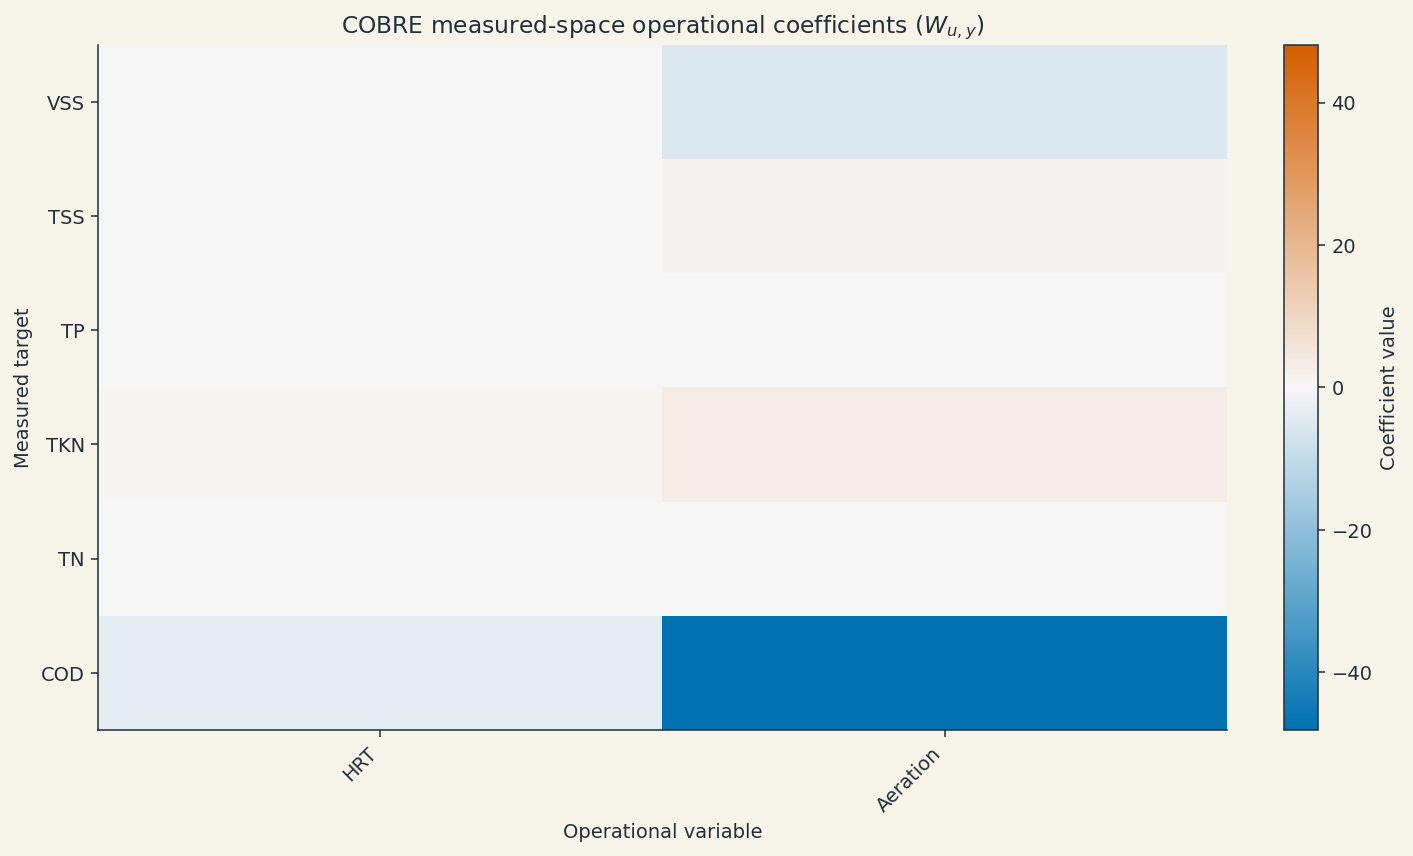

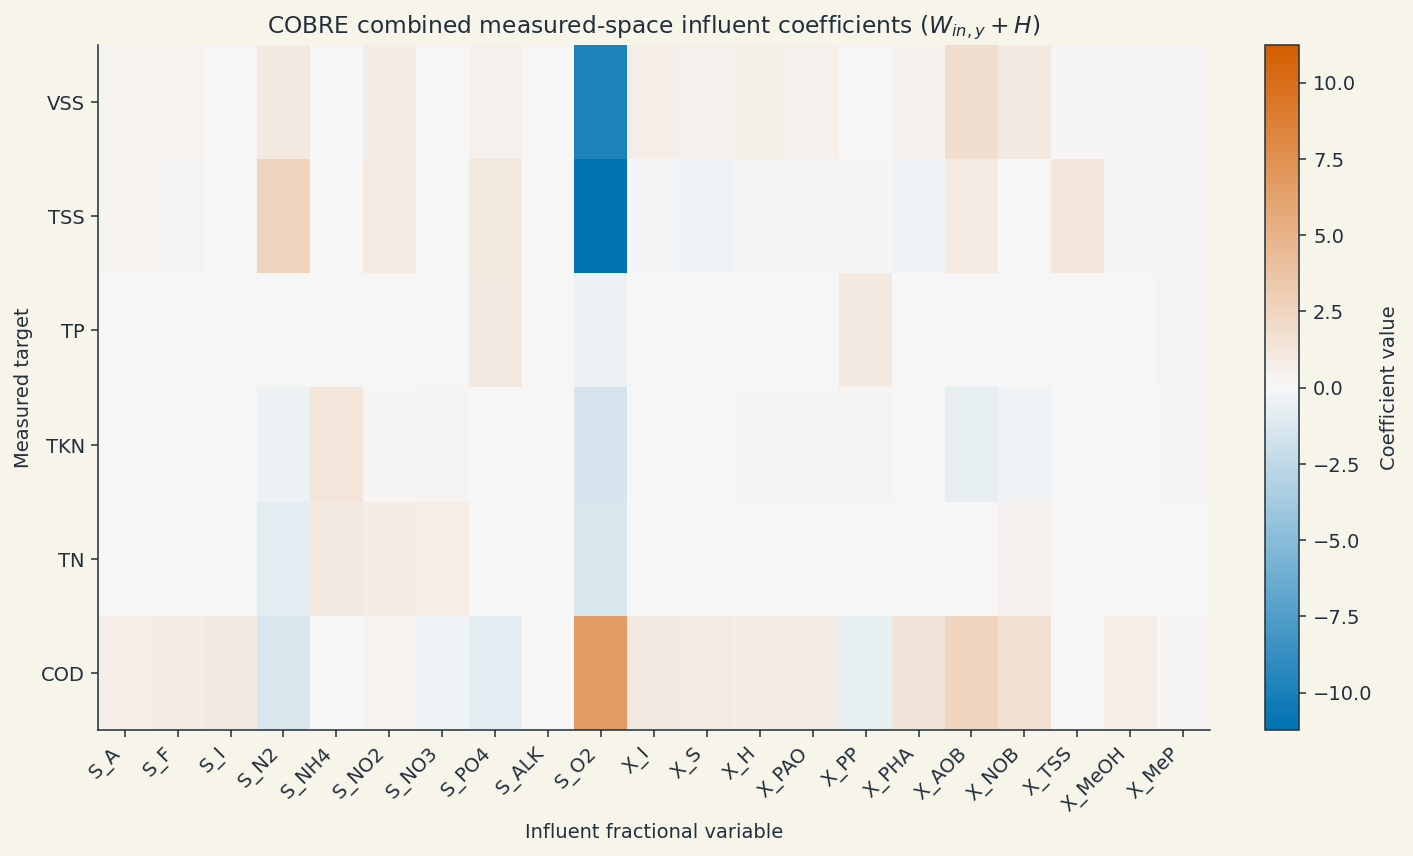

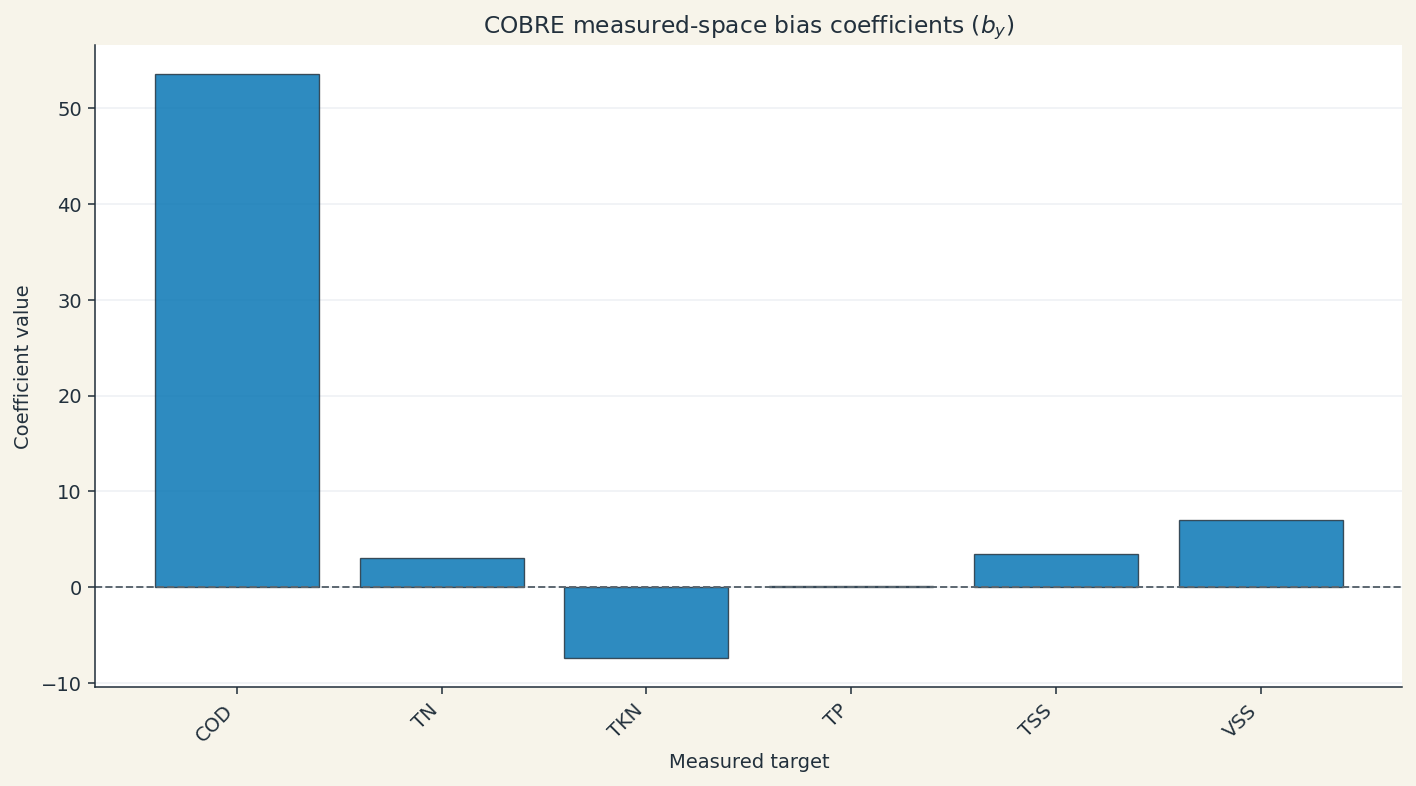

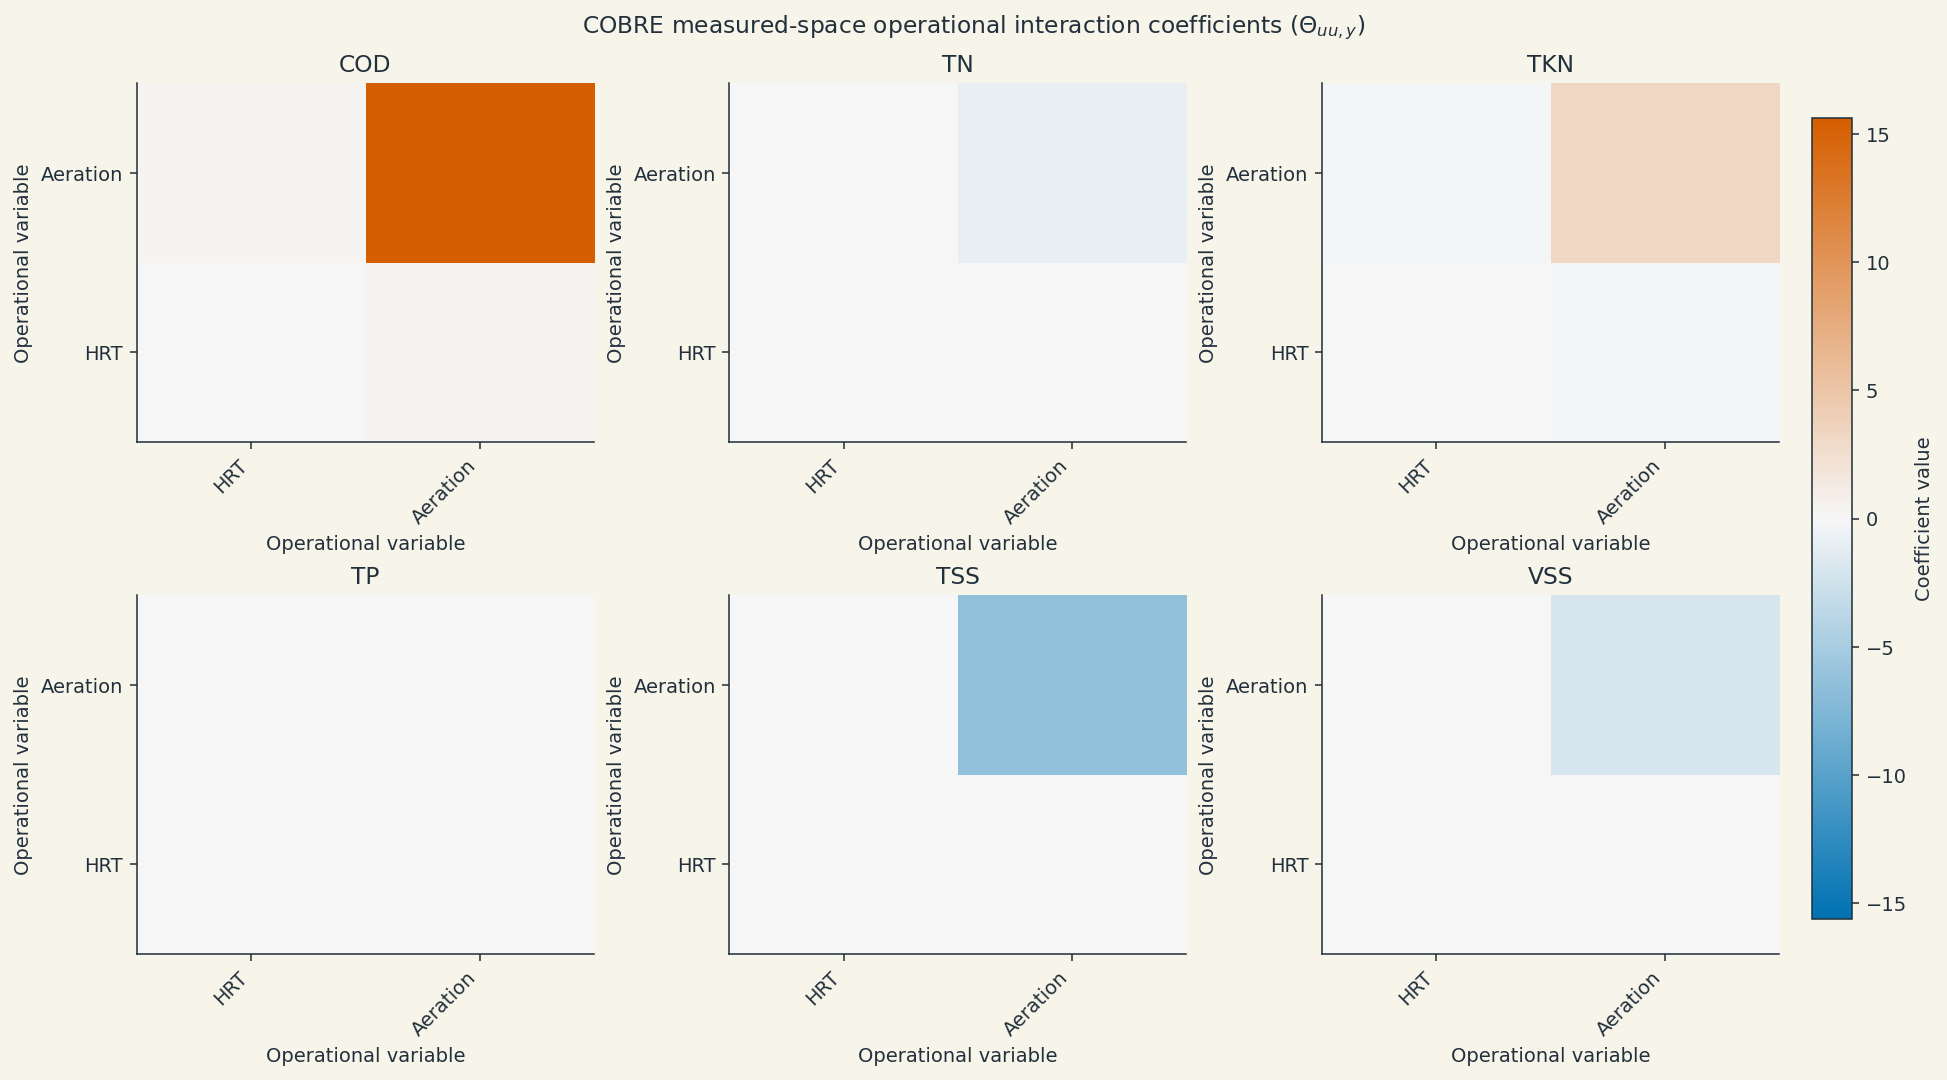

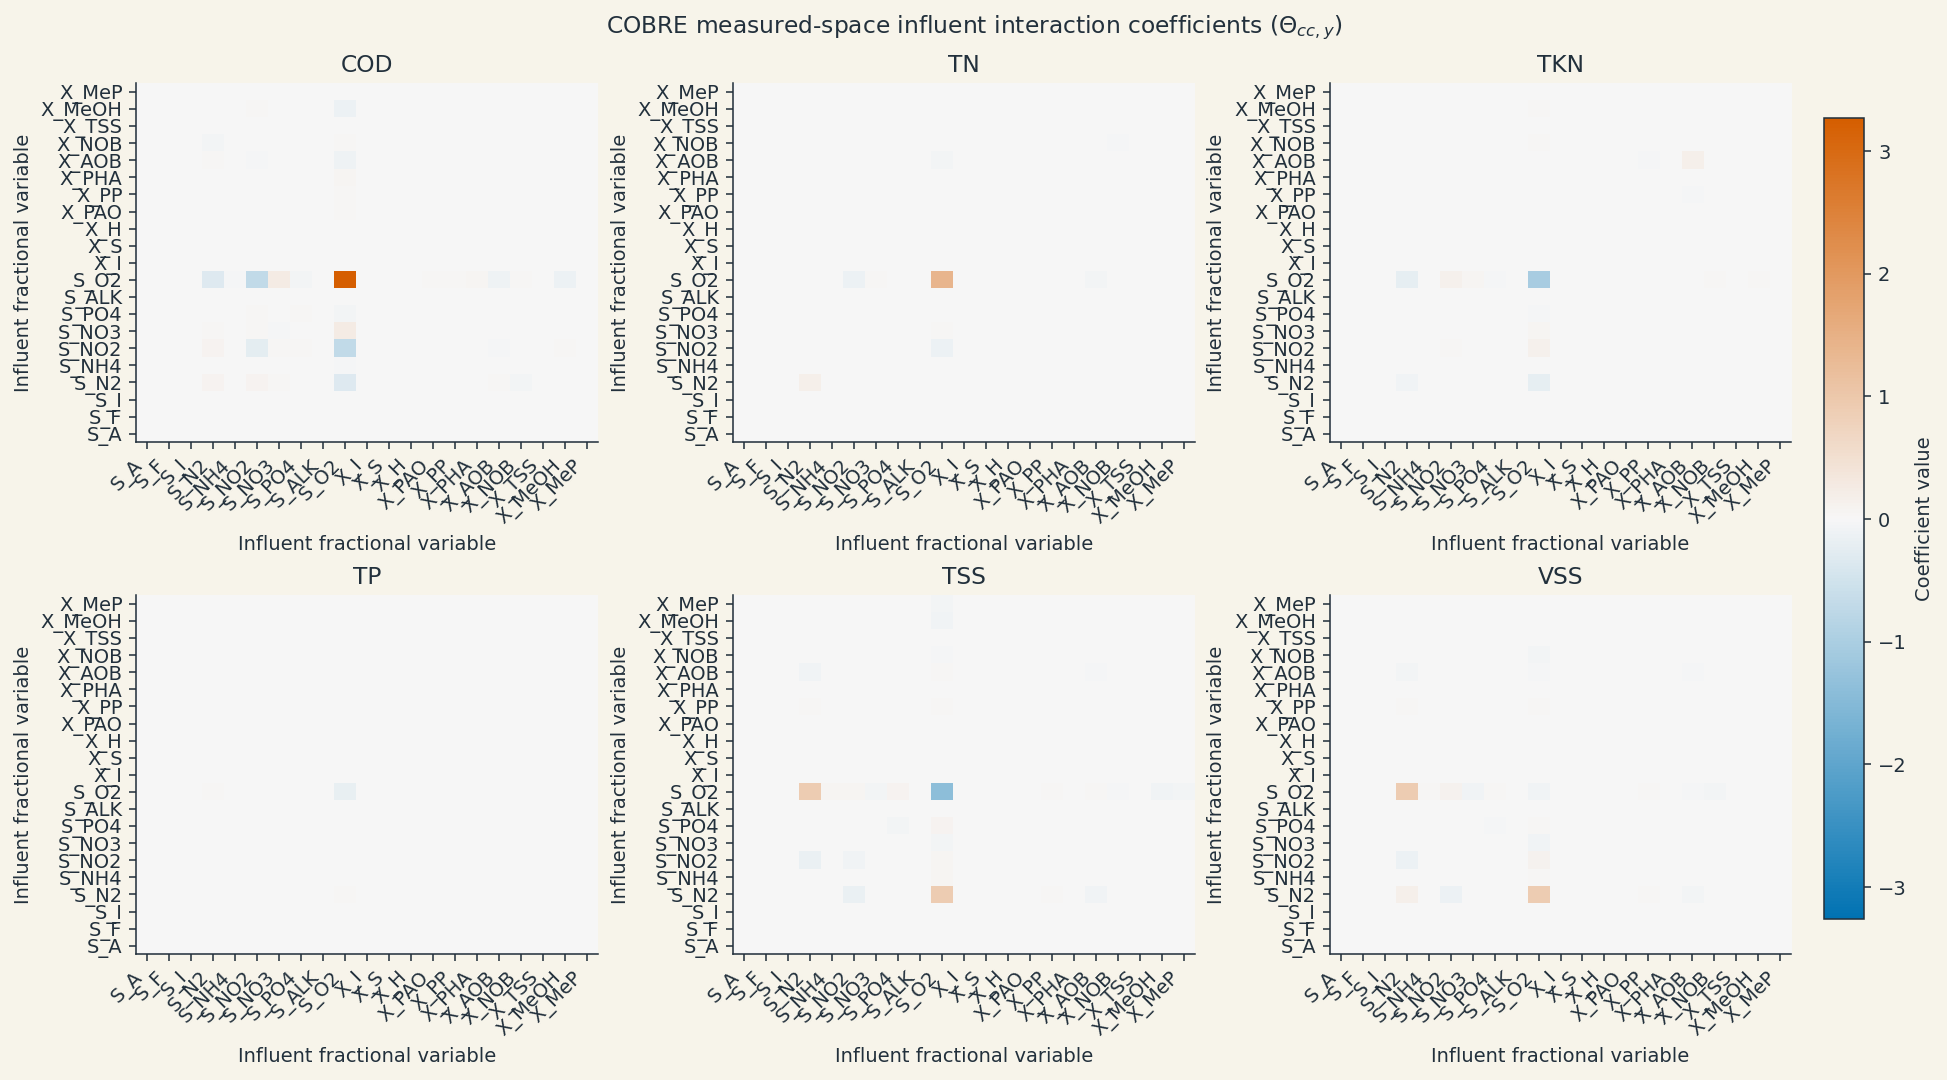

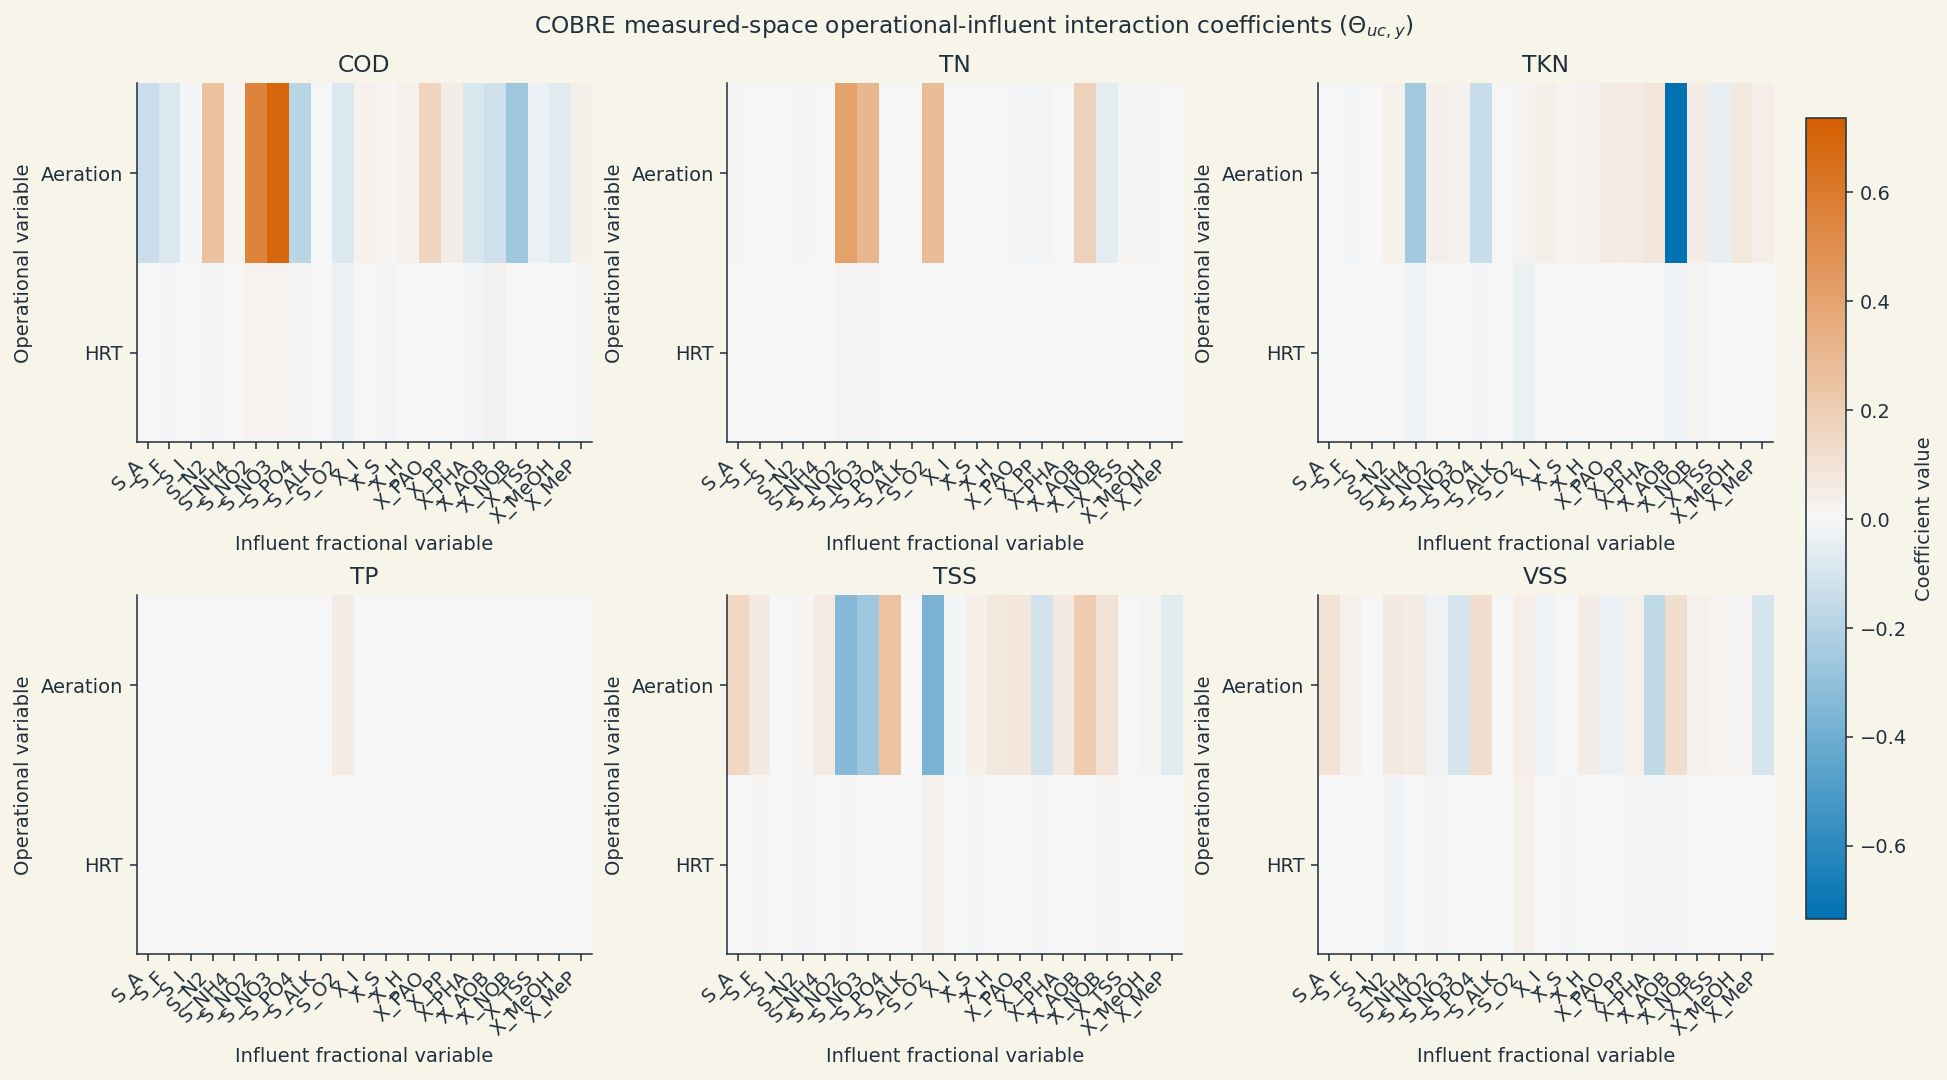

In [18]:
import matplotlib.pyplot as plt

from src.utils.plot import (
    plot_coefficient_bar_chart,
    plot_coefficient_heatmap,
    plot_coefficient_tensor_heatmaps,
)

effective_coefficients = cobre_result["model_bundle"]["effective_coefficients"]
measured_targets = list(metadata["measured_output_columns"])
operational_variables = list(metadata["operational_columns"])
influent_fractional_variables = list(metadata["state_columns"])

figure, _ = plot_coefficient_heatmap(
    effective_coefficients["W_u"],
    row_labels=measured_targets,
    column_labels=operational_variables,
    title=r"COBRE measured-space operational coefficients ($W_{u,y}$)",
    x_label="Operational variable",
    y_label="Measured target",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_heatmap(
    effective_coefficients["W_in"],
    row_labels=measured_targets,
    column_labels=influent_fractional_variables,
    title=r"COBRE combined measured-space influent coefficients ($W_{in,y} + H$)",
    x_label="Influent fractional variable",
    y_label="Measured target",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_bar_chart(
    effective_coefficients["b"],
    labels=measured_targets,
    title=r"COBRE measured-space bias coefficients ($b_y$)",
    x_label="Measured target",
    y_label="Coefficient value",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_tensor_heatmaps(
    effective_coefficients["Theta_uu"],
    target_labels=measured_targets,
    row_labels=operational_variables,
    column_labels=operational_variables,
    title=r"COBRE measured-space operational interaction coefficients ($\Theta_{uu,y}$)",
    x_label="Operational variable",
    y_label="Operational variable",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_tensor_heatmaps(
    effective_coefficients["Theta_cc"],
    target_labels=measured_targets,
    row_labels=influent_fractional_variables,
    column_labels=influent_fractional_variables,
    title=r"COBRE measured-space influent interaction coefficients ($\Theta_{cc,y}$)",
    x_label="Influent fractional variable",
    y_label="Influent fractional variable",
)
display(figure)
plt.close(figure)

figure, _ = plot_coefficient_tensor_heatmaps(
    effective_coefficients["Theta_uc"],
    target_labels=measured_targets,
    row_labels=operational_variables,
    column_labels=influent_fractional_variables,
    title=r"COBRE measured-space operational-influent interaction coefficients ($\Theta_{uc,y}$)",
    x_label="Influent fractional variable",
    y_label="Operational variable",
)
display(figure)
plt.close(figure)

## COBRE Response Surface

This block fixes the influent fractional states to a common profile and then evaluates the trained COBRE model over an extended HRT-Aeration grid. By default the fixed influent profile uses the midpoint of each configured influent-state range, and the operational grid extends 50% beyond the original training domain while clipping the lower HRT and Aeration bounds at zero so the operating points remain physically valid.

Override any of the defaults by defining `cobre_response_surface_overrides = {...}` before running the next cell.

COBRE response-surface analysis complete.
Fixed influent profile strategy: midpoint
Extended HRT range: 0.000 to 51.000
Extended Aeration range: 0.000 to 3.500
COBRE response-surface configuration
This table lists the configuration used to build the COBRE response-surface grid, including the grid density, the extrapolation range, and the fixed influent-profile strategy.


,grid_points_per_axis,contour_levels,operational_extension_fraction,fixed_influent_profile
0,1000,100,0.5,midpoint


COBRE fixed influent profile
This table shows the influent fractional-state profile that is held constant while the HRT-Aeration response surface is evaluated.


,value
S_A,42.50
S_F,100.00
S_I,50.00
S_N2,1.00
S_NH4,33.50
S_NO2,1.50
S_NO3,4.00
S_PO4,10.00
S_ALK,170.00
S_O2,0.25


COBRE response-surface prediction preview
This table previews the response-surface prediction grid, including the operational coordinates, the fixed constraint reference, the projected measured-output predictions, and any returned uncertainty columns.


,HRT,Aeration,In_S_A,In_S_F,In_S_I,In_S_N2,In_S_NH4,In_S_NO2,In_S_NO3,In_S_PO4,...,ProjectedPI95Lower_Out_TKN,ProjectedPI95Lower_Out_TP,ProjectedPI95Lower_Out_TSS,ProjectedPI95Lower_Out_VSS,ProjectedPI95Upper_Out_COD,ProjectedPI95Upper_Out_TN,ProjectedPI95Upper_Out_TKN,ProjectedPI95Upper_Out_TP,ProjectedPI95Upper_Out_TSS,ProjectedPI95Upper_Out_VSS
0,0.000000,0.0,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,-656.321094,-33.805514,-1640.427031,-1203.330158,2476.161418,366.371589,849.859437,94.994203,1664.043874,1636.473271
1,0.051051,0.0,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,-656.306199,-33.805084,-1640.429126,-1203.425960,2475.772046,366.367310,849.881962,94.995285,1664.058520,1636.391855
2,0.102102,0.0,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,-656.291315,-33.804655,-1640.431179,-1203.521687,2475.383170,366.363037,849.904476,94.996366,1664.073206,1636.310514
3,0.153153,0.0,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,-656.276442,-33.804227,-1640.433192,-1203.617339,2474.994791,366.358770,849.926980,94.997447,1664.087933,1636.229248
4,0.204204,0.0,42.5,100.0,50.0,1.0,33.5,1.5,4.0,10.0,...,-656.261580,-33.803800,-1640.435165,-1203.712916,2474.606909,366.354509,849.949472,94.998527,1664.102700,1636.148057


COBRE response-surface prediction uncertainty summary
This table summarizes the average widths and standard errors of the projected COBRE response-surface confidence and prediction intervals over the evaluated grid.


,target,mean_standard_error_mean,mean_standard_error_max,prediction_standard_error_mean,prediction_standard_error_max,mean_confidence_interval_width_mean,prediction_interval_width_mean
0,Out_COD,946.304511,948.916105,946.358130,948.969576,3710.026888,3710.237101
1,Out_TN,157.957645,158.393573,157.966595,158.402499,619.279631,619.314720
2,Out_TKN,385.224648,386.287784,385.246475,386.309551,1510.289537,1510.375111
3,Out_TP,32.942150,33.033063,32.944017,33.034925,129.151094,129.158412
4,Out_TSS,845.160069,847.492526,845.207956,847.540282,3313.485821,3313.673565
5,Out_VSS,726.315507,728.319980,726.356661,728.361020,2847.550686,2847.712031


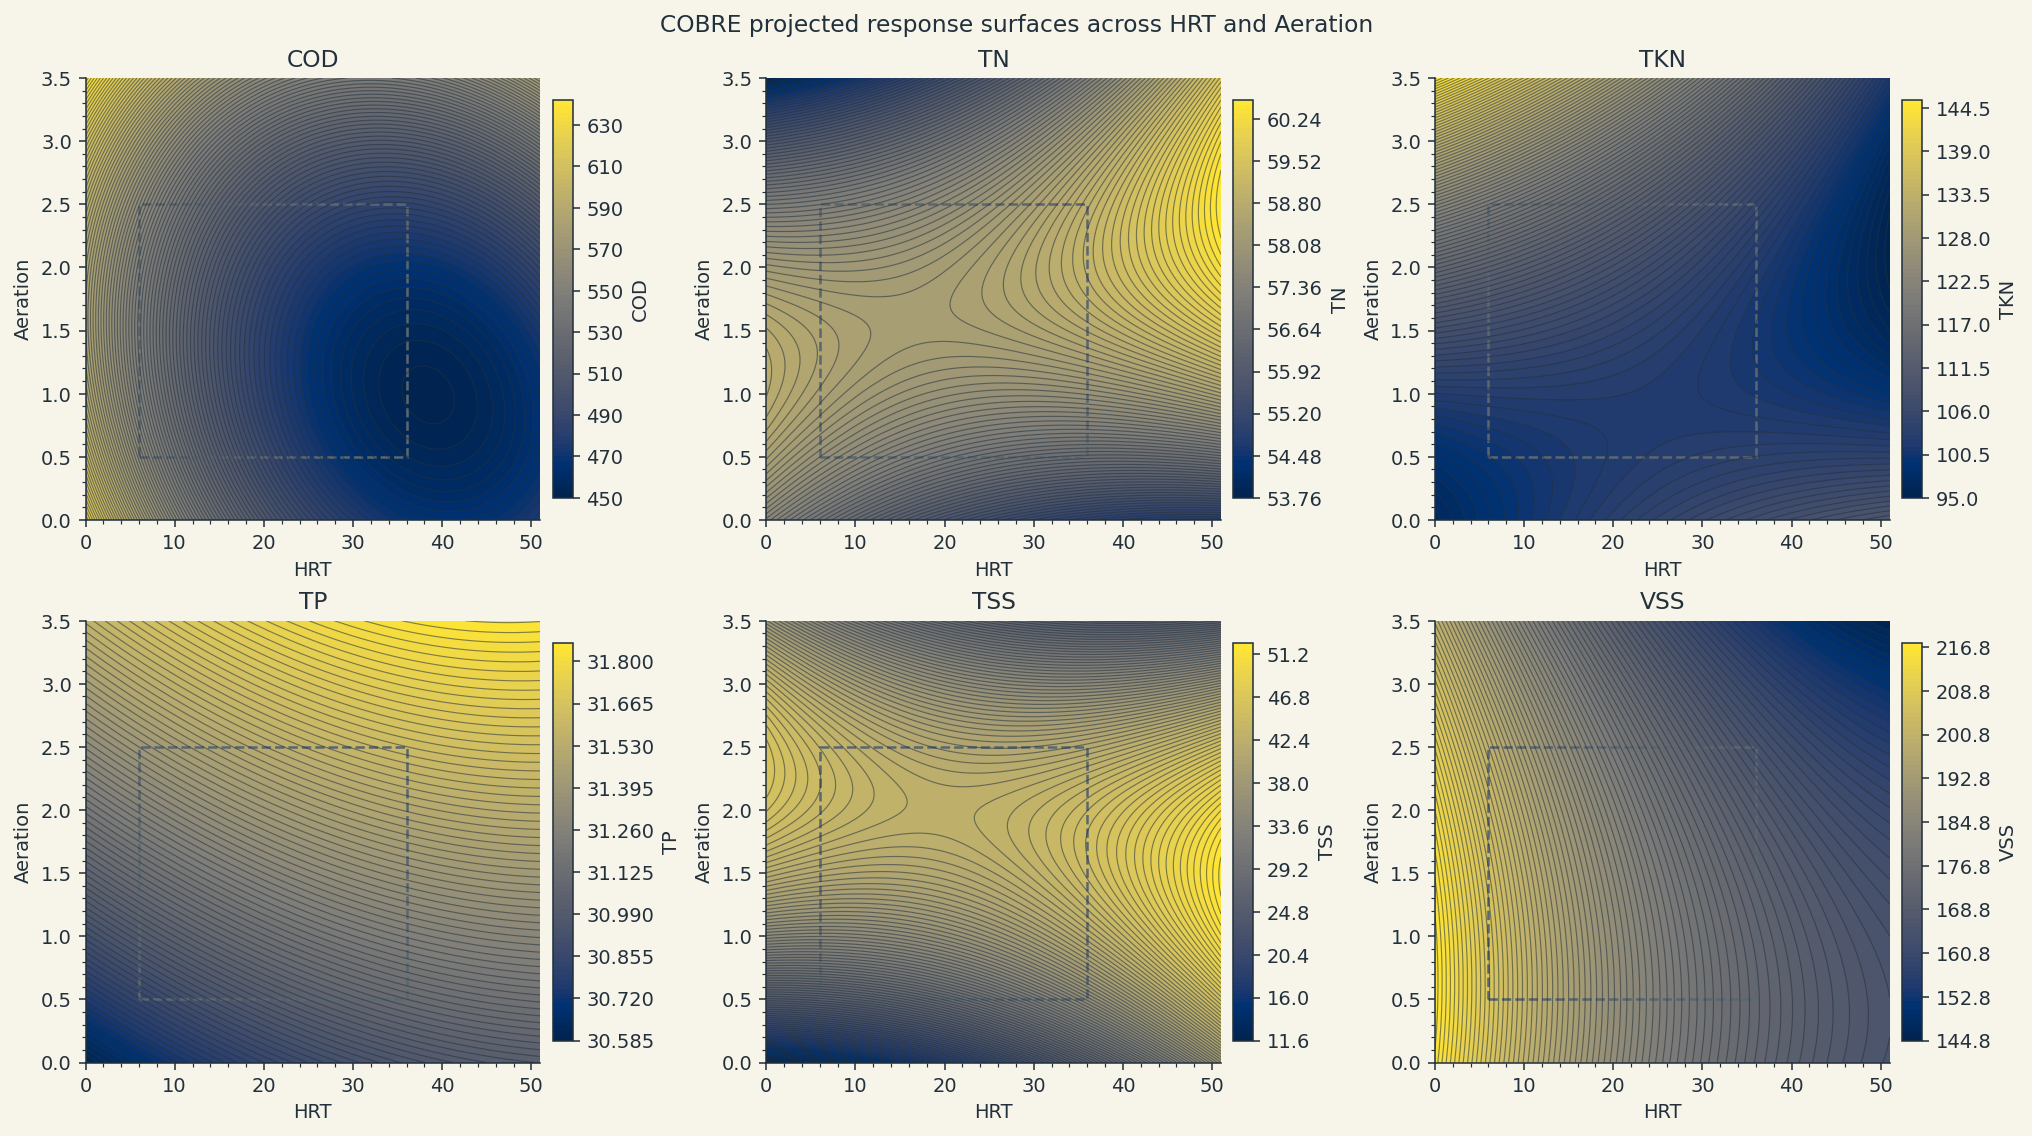

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

from src.utils.analysis import (
    build_cobre_response_surface_prediction_data,
    describe_and_display_table,
    load_cobre_response_surface_defaults,
    )
from src.utils.plot import plot_response_surface_contours

cobre_response_surface_defaults = load_cobre_response_surface_defaults()
cobre_response_surface_overrides = dict(globals().get("cobre_response_surface_overrides", {}))
cobre_response_surface_config = {
    **cobre_response_surface_defaults,
    **cobre_response_surface_overrides,
    }

cobre_model_path = cobre_result["artifact_paths"]["model_bundle"]
if cobre_model_path is None:
    raise ValueError("COBRE model bundle path is required to generate the response-surface plot.")

cobre_response_surface_result = build_cobre_response_surface_prediction_data(
    cobre_model_path,
    metadata=metadata,
    grid_points_per_axis=int(cobre_response_surface_config["grid_points_per_axis"]),
    operational_extension_fraction=float(
        cobre_response_surface_config["operational_extension_fraction"]
        ),
    fixed_influent_profile=cobre_response_surface_config["fixed_influent_profile"],
    )

print("COBRE response-surface analysis complete.")
print(
    "Fixed influent profile strategy: "
    f"{cobre_response_surface_result['response_surface_config']['fixed_influent_profile']}"
    )
print(
    "Extended HRT range: "
    f"{cobre_response_surface_result['extended_domain']['HRT']['min']:.3f} to "
    f"{cobre_response_surface_result['extended_domain']['HRT']['max']:.3f}"
    )
print(
    "Extended Aeration range: "
    f"{cobre_response_surface_result['extended_domain']['Aeration']['min']:.3f} to "
    f"{cobre_response_surface_result['extended_domain']['Aeration']['max']:.3f}"
    )

describe_and_display_table(
    "COBRE response-surface configuration",
    "This table lists the configuration used to build the COBRE response-surface grid, including the grid density, the extrapolation range, and the fixed influent-profile strategy.",
    pd.DataFrame([cobre_response_surface_config]),
    )
describe_and_display_table(
    "COBRE fixed influent profile",
    "This table shows the influent fractional-state profile that is held constant while the HRT-Aeration response surface is evaluated.",
    cobre_response_surface_result["fixed_influent_profile"].to_frame(),
    )
describe_and_display_table(
    "COBRE response-surface prediction preview",
    "This table previews the response-surface prediction grid, including the operational coordinates, the fixed constraint reference, the projected measured-output predictions, and any returned uncertainty columns.",
    cobre_response_surface_result["prediction_table"].head(),
    )
if "prediction_uncertainty_summary" in cobre_response_surface_result:
    describe_and_display_table(
        "COBRE response-surface prediction uncertainty summary",
        "This table summarizes the average widths and standard errors of the projected COBRE response-surface confidence and prediction intervals over the evaluated grid.",
        cobre_response_surface_result["prediction_uncertainty_summary"],
        )

figure, _ = plot_response_surface_contours(
    cobre_response_surface_result["operational_meshes"]["HRT"],
    cobre_response_surface_result["operational_meshes"]["Aeration"],
    cobre_response_surface_result["per_target_surfaces"],
    title="COBRE projected response surfaces across HRT and Aeration",
    x_label="HRT",
    y_label="Aeration",
    training_domain=cobre_response_surface_result["training_domain"],
    contour_levels=int(cobre_response_surface_config["contour_levels"]),
    )
display(figure)
plt.close(figure)

## Additional Classical Regressors

The notebook now benchmarks the classical regressors on the same train-test rows, the same operational inputs, the same influent fractional-state inputs, and the same measured-output targets used by COBRE. The optional Optuna subset is drawn only from the shared training pool, and the direct cross-model comparison should be interpreted from the measured-output metrics rather than the model-native diagnostic tables.

In [9]:
import pandas as pd

from src.models.ml import (
    load_adaboost_regressor_params,
    load_catboost_regressor_params,
    load_lightgbm_regressor_params,
    load_random_forest_regressor_params,
    load_svr_regressor_params,
    load_xgboost_regressor_params,
    run_adaboost_regressor_pipeline,
    run_catboost_regressor_pipeline,
    run_lightgbm_regressor_pipeline,
    run_random_forest_regressor_pipeline,
    run_svr_regressor_pipeline,
    run_xgboost_regressor_pipeline,
)
from src.models.ml.adaboost_regressor import build_adaboost_regressor_model
from src.models.ml.catboost_regressor import build_catboost_regressor_model
from src.models.ml.lightgbm_regressor import build_lightgbm_regressor_model
from src.models.ml.random_forest_regressor import build_random_forest_regressor_model
from src.models.ml.svr_regressor import build_svr_regressor_model
from src.models.ml.xgboost_regressor import build_xgboost_regressor_model
from src.utils.analysis import build_negative_prediction_tables, describe_and_display_table
from src.utils.train import tune_tabular_regressor_hyperparameters

classical_regressor_specs = {
    "xgboost_regressor": {
        "load_params": load_xgboost_regressor_params,
        "build_model": build_xgboost_regressor_model,
        "runner": run_xgboost_regressor_pipeline,
    },
    "lightgbm_regressor": {
        "load_params": load_lightgbm_regressor_params,
        "build_model": build_lightgbm_regressor_model,
        "runner": run_lightgbm_regressor_pipeline,
    },
    "catboost_regressor": {
        "load_params": load_catboost_regressor_params,
        "build_model": build_catboost_regressor_model,
        "runner": run_catboost_regressor_pipeline,
    },
    "adaboost_regressor": {
        "load_params": load_adaboost_regressor_params,
        "build_model": build_adaboost_regressor_model,
        "runner": run_adaboost_regressor_pipeline,
    },
    "random_forest_regressor": {
        "load_params": load_random_forest_regressor_params,
        "build_model": build_random_forest_regressor_model,
        "runner": run_random_forest_regressor_pipeline,
    },
    "svr_regressor": {
        "load_params": load_svr_regressor_params,
        "build_model": build_svr_regressor_model,
        "runner": run_svr_regressor_pipeline,
    },
}

def run_classical_regressor(
    model_name: str,
    *,
    use_optuna: bool = False,
    persist_artifacts: bool = True,
):
    spec = classical_regressor_specs[model_name]
    model_params = spec["load_params"]()
    selected_hyperparameters = dict(model_params["training_defaults"])
    optuna_summary = None

    if use_optuna:
        selected_hyperparameters, optuna_summary = tune_tabular_regressor_hyperparameters(
            model_name,
            spec["build_model"],
            tuning_dataset_splits.train,
            tuning_dataset_splits.test,
            A_matrix=A_matrix,
            model_params=model_params,
            n_trials=int(ml_orchestration["n_trials"]),
            timeout=ml_orchestration["timeout_seconds"],
        )

    result = spec["runner"](
        main_dataset_splits.train,
        main_dataset_splits.test,
        A_matrix,
        model_params=model_params,
        model_hyperparameters=selected_hyperparameters,
        optuna_summary=optuna_summary,
        persist_artifacts=persist_artifacts,
    )

    projection_active = bool(result["test_report"]["report_metadata"].loc[0, "projection_active"])
    negative_prediction_tables = build_negative_prediction_tables(
        {
            "train": result["train_report"],
            "test": result["test_report"],
        }
    )
    result["negative_prediction_summary"] = negative_prediction_tables["summary"]
    result["negative_prediction_per_target"] = negative_prediction_tables["per_target"]
    selected_test_prediction_type = (
        "projected"
        if "projected_predictions" in result["test_report"]
        else "raw"
    )
    selected_test_negative_summary = result["negative_prediction_summary"].loc[
        (result["negative_prediction_summary"]["split"] == "test")
        & (
            result["negative_prediction_summary"]["prediction_type"]
            == selected_test_prediction_type
        )
    ].iloc[0]

    print(f"{model_name} training complete.")
    print("This benchmark run uses the same operational-plus-fractional inputs, the same measured targets, and the same train-test rows used by COBRE.")
    if projection_active:
        print("Classical measured-space post-projection is active for this model because the measured-output null space is non-trivial.")
    else:
        print("Classical measured-space post-projection is inactive for this model because the measured-output null space is trivial.")
        print("Projected classical outputs and measured-space discrepancy summaries are therefore omitted below.")
    print(f"Saved model bundle: {result['artifact_paths']['model_bundle']}")
    print(f"Saved metrics summary: {result['artifact_paths']['metrics']}")
    print(f"Saved Optuna summary: {result['artifact_paths']['optuna']}")
    print(
        f"{model_name} {selected_test_prediction_type} test predictions are negative in "
        f"{int(selected_test_negative_summary['negative_predictions'])} of "
        f"{int(selected_test_negative_summary['total_predictions'])} predicted target values "
        f"({selected_test_negative_summary['negative_prediction_rate_pct']:.2f}%)."
    )

    describe_and_display_table(
        f"{model_name} report metadata",
        "This table explains the reporting contract for the current classical model. Measured-output metrics are directly comparable with COBRE, and trivial measured-space null spaces are marked as inactive rather than treated as successful zero-violation results.",
        result["test_report"]["report_metadata"],
    )
    describe_and_display_table(
        f"{model_name} hyperparameters",
        "This table lists the hyperparameters used to fit the current classical benchmark model.",
        pd.DataFrame([result["best_hyperparameters"]]),
    )
    describe_and_display_table(
        f"{model_name} train aggregate metrics",
        "This table reports the train-split measured-output metrics for the current classical model. These values are directly comparable with COBRE under the shared benchmark contract.",
        result["train_report"]["aggregate_metrics"],
    )
    describe_and_display_table(
        f"{model_name} test aggregate metrics",
        "This table reports the test-split measured-output metrics for the current classical model. These values are directly comparable with COBRE under the shared benchmark contract.",
        result["test_report"]["aggregate_metrics"],
    )
    describe_and_display_table(
        f"{model_name} test per-target metrics",
        "This table breaks down the current classical model's test metrics by measured-output target.",
        result["test_report"]["per_target_metrics"],
    )
    describe_and_display_table(
        f"{model_name} negative prediction incidence summary",
        "This table summarizes how often the current classical model produces negative measured-output predictions on the train and test splits. When measured-space post-projection is active, both raw and projected predictions are reported; otherwise only the raw predictions are shown.",
        result["negative_prediction_summary"],
    )
    describe_and_display_table(
        f"{model_name} negative prediction incidence by target",
        "This table breaks down the negative-prediction incidence by measured-output target for the current classical model, including counts, rates, and the observed magnitude of the negative predictions for each available prediction type.",
        result["negative_prediction_per_target"],
    )
    if projection_active:
        describe_and_display_table(
            f"{model_name} test diagnostic summary",
            "This table summarizes model-native diagnostics for the current classical model, including measured-space constraint residuals and raw-to-projected adjustment magnitudes. These diagnostics are complementary to, but distinct from, COBRE's fractional diagnostics.",
            result["test_report"]["diagnostic_summary"],
        )
        describe_and_display_table(
            f"{model_name} test constraint residual summary",
            "This table summarizes the sample-level measured-space constraint residual norms on the current classical model's test split.",
            result["test_report"]["constraint_residuals"].describe().T,
        )

    return result

classical_regressor_results = {}

for model_name in classical_regressor_specs:
    print(f"\n=== Running {model_name} ===")
    classical_regressor_results[model_name] = run_classical_regressor(
        model_name,
        use_optuna=USE_OPTUNA,
        persist_artifacts=True,
    )

list(classical_regressor_results)


=== Running xgboost_regressor ===


xgboost_regressor training complete.
This benchmark run uses the same operational-plus-fractional inputs, the same measured targets, and the same train-test rows used by COBRE.
Classical measured-space post-projection is inactive for this model because the measured-output null space is trivial.
Projected classical outputs and measured-space discrepancy summaries are therefore omitted below.
Saved model bundle: C:\Users\eselerio\projects\pibre-model\results\xgboost_regressor\model_20260401_063144.pkl
Saved metrics summary: C:\Users\eselerio\projects\pibre-model\results\xgboost_regressor\metrics_20260401_063144.json
Saved Optuna summary: None
xgboost_regressor raw test predictions are negative in 0 of 12000 predicted target values (0.00%).
xgboost_regressor report metadata
This table explains the reporting contract for the current classical model. Measured-output metrics are directly comparable with COBRE, and trivial measured-space null spaces are marked as inactive rather than treated 

,native_prediction_space,comparison_target_space,constraint_space,direct_comparison_scope,diagnostic_scope,projection_active,constraint_status
0,measured,measured,measured,measured_output_metrics_only,projection_inactive_trivial_measured_null_space,False,inactive_trivial_null_space


xgboost_regressor hyperparameters
This table lists the hyperparameters used to fit the current classical benchmark model.


,objective,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,tree_method,random_state,n_jobs,verbosity
0,reg:squarederror,200,0.05,6,1.0,0.9,0.9,0.000001,1.0,hist,42,-1,0


...

svr_regressor negative prediction incidence summary
This table summarizes how often the current classical model produces negative measured-output predictions on the train and test splits. When measured-space post-projection is active, both raw and projected predictions are reported; otherwise only the raw predictions are shown.


,split,prediction_type,total_predictions,negative_predictions,negative_prediction_rate_pct,total_samples,samples_with_any_negative,sample_incidence_rate_pct,avg_negative_targets_per_affected_sample,minimum_prediction,mean_negative_prediction,median_negative_prediction
0,train,raw,48000,0,0.0,8000,0,0.0,0.0,7.454742,NaN,NaN
1,test,raw,12000,0,0.0,2000,0,0.0,0.0,9.933931,NaN,NaN


svr_regressor negative prediction incidence by target
This table breaks down the negative-prediction incidence by measured-output target for the current classical model, including counts, rates, and the observed magnitude of the negative predictions for each available prediction type.


,split,prediction_type,target,negative_predictions,negative_prediction_rate_pct,minimum_prediction,mean_negative_prediction,median_negative_prediction
0,test,raw,Out_TP,0,0.0,9.933931,NaN,NaN
1,test,raw,Out_TKN,0,0.0,12.797421,NaN,NaN
2,test,raw,Out_TN,0,0.0,28.673445,NaN,NaN
3,test,raw,Out_VSS,0,0.0,128.754650,NaN,NaN
4,test,raw,Out_TSS,0,0.0,173.875996,NaN,NaN
5,test,raw,Out_COD,0,0.0,203.607827,NaN,NaN
6,train,raw,Out_TP,0,0.0,7.454742,NaN,NaN
7,train,raw,Out_TKN,0,0.0,13.158493,NaN,NaN
8,train,raw,Out_TN,0,0.0,25.665172,NaN,NaN
9,train,raw,Out_VSS,0,0.0,120.941759,NaN,NaN


['xgboost_regressor',
 'lightgbm_regressor',
 'catboost_regressor',
 'adaboost_regressor',
 'random_forest_regressor',
 'svr_regressor']

## Analysis

Each code cell below runs the configurable dataset-size sweep for one model under the shared benchmark contract used by the main training sections. The boxplots compare measured-output metrics across train and test splits, while any additional diagnostic tables remain model-native and should not be interpreted as direct apples-to-apples ranking metrics across COBRE and the classical regressors.

Analyze cobre: 100%|██████████| 110/110 [17:55<00:00,  9.77s/run, repeat=10, size=1e+4]

COBRE analysis complete.
Metric: projected_MSE
Prediction tables returned: 220
COBRE analysis configuration
This table lists the dataset-size sweep configuration used to evaluate COBRE under repeated train-test resampling.


,min_total_samples,max_total_samples,total_sample_step,n_repeats,test_fraction,random_seed
0,100,10000,990,10,0.2,42


COBRE analysis run metadata preview
This table previews the run-level metadata for the COBRE analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.


,model_name,dataset_size_total,repeat_index,train_size,test_size,run_seed,artifact_model_bundle_path,artifact_metrics_path,artifact_optuna_path
0,cobre,100,0,80,20,42,None,None,None
1,cobre,100,1,80,20,43,None,None,None
2,cobre,100,2,80,20,44,None,None,None
3,cobre,100,3,80,20,45,None,None,None
4,cobre,100,4,80,20,46,None,None,None


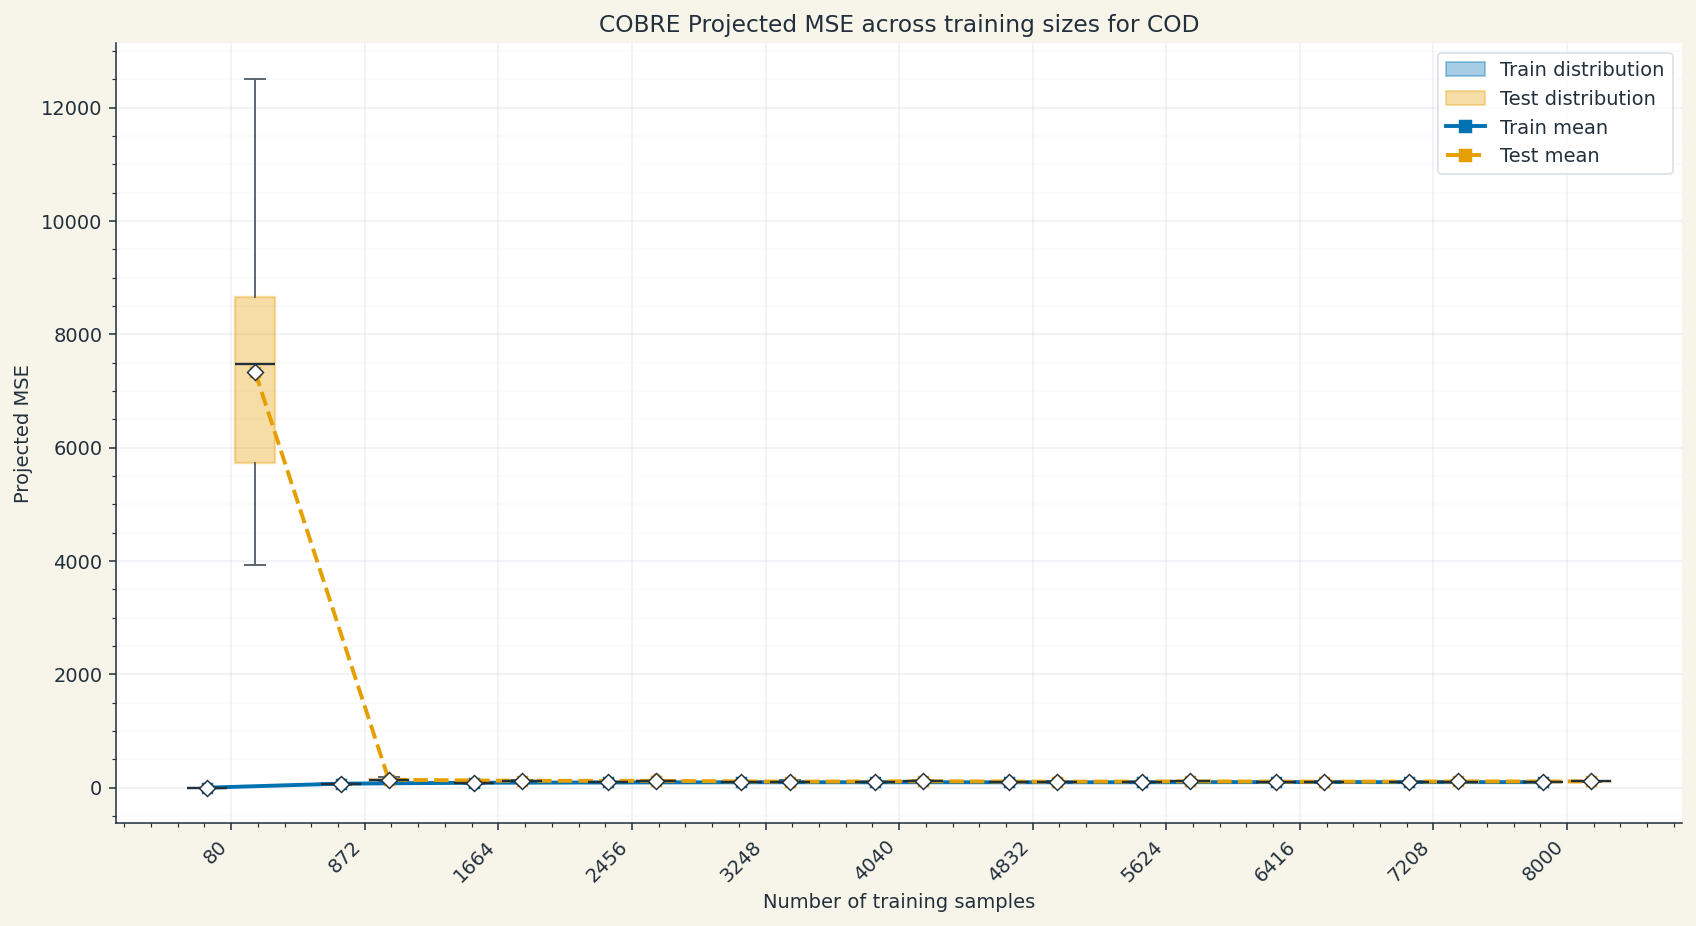

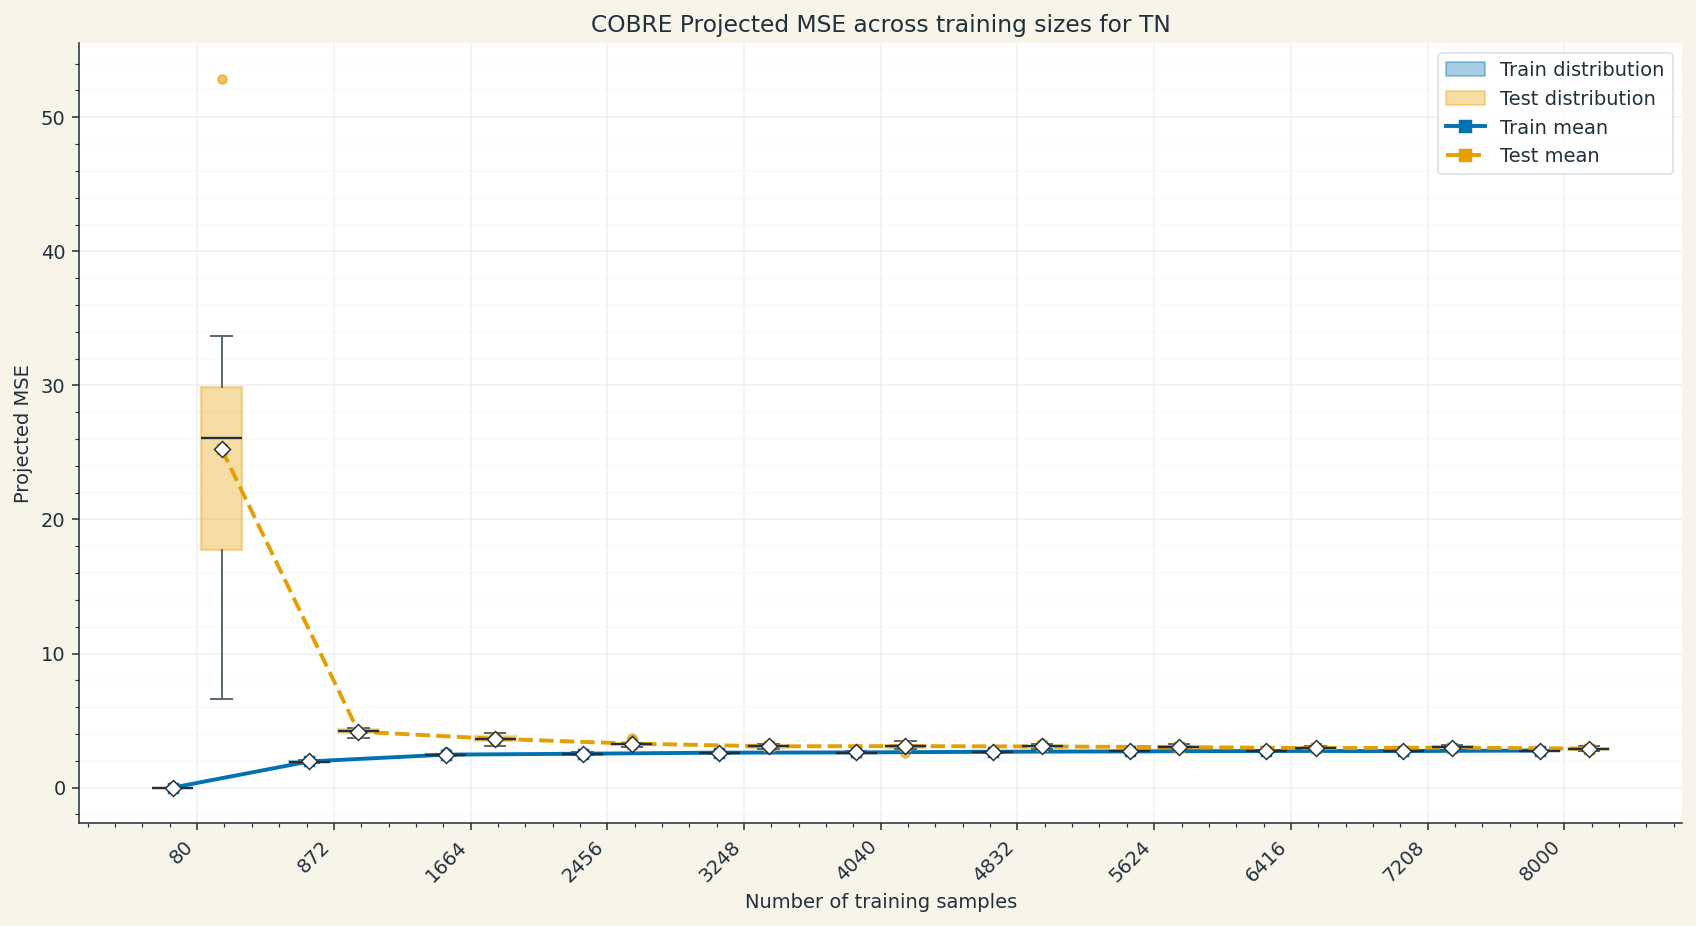

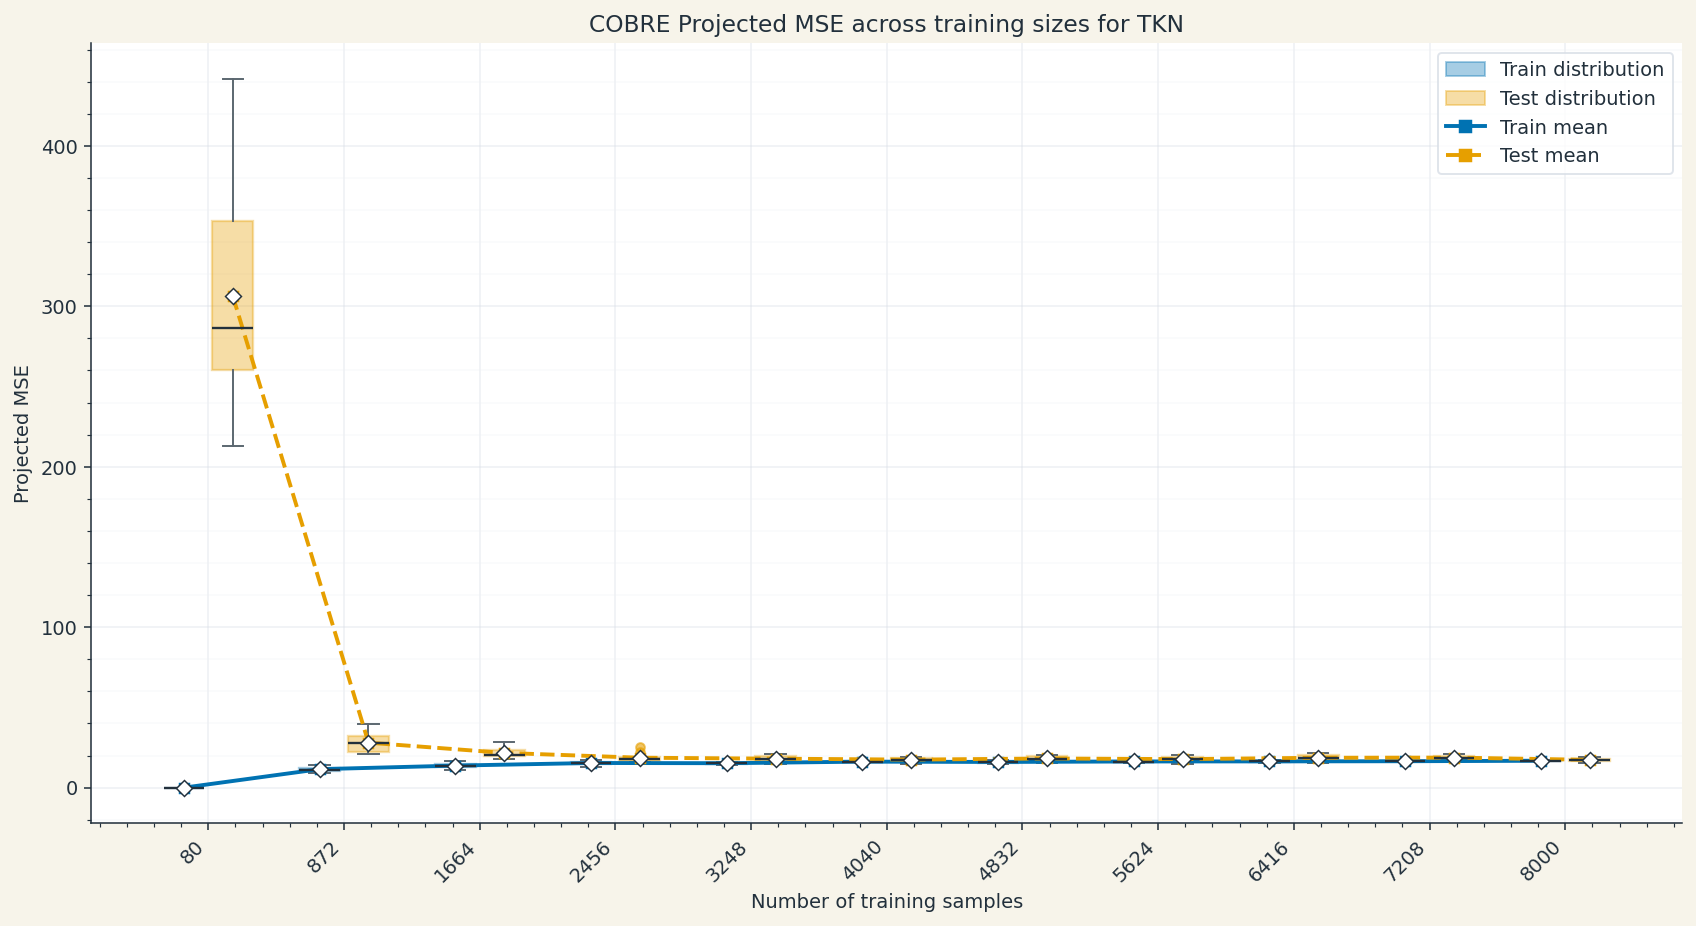

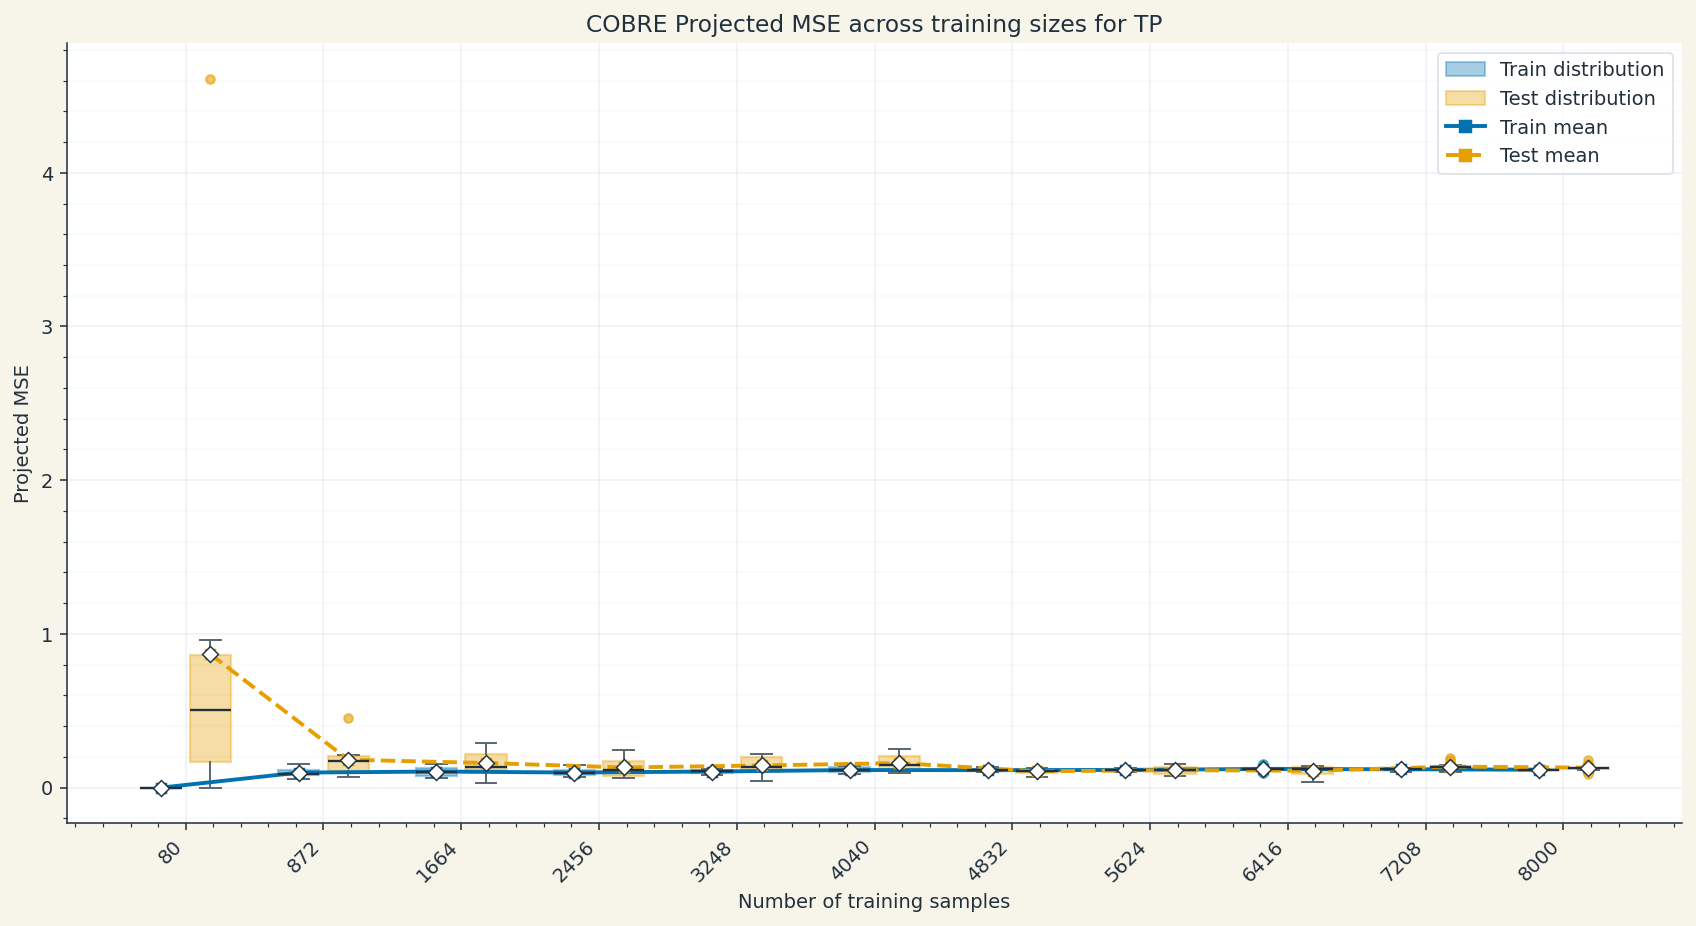

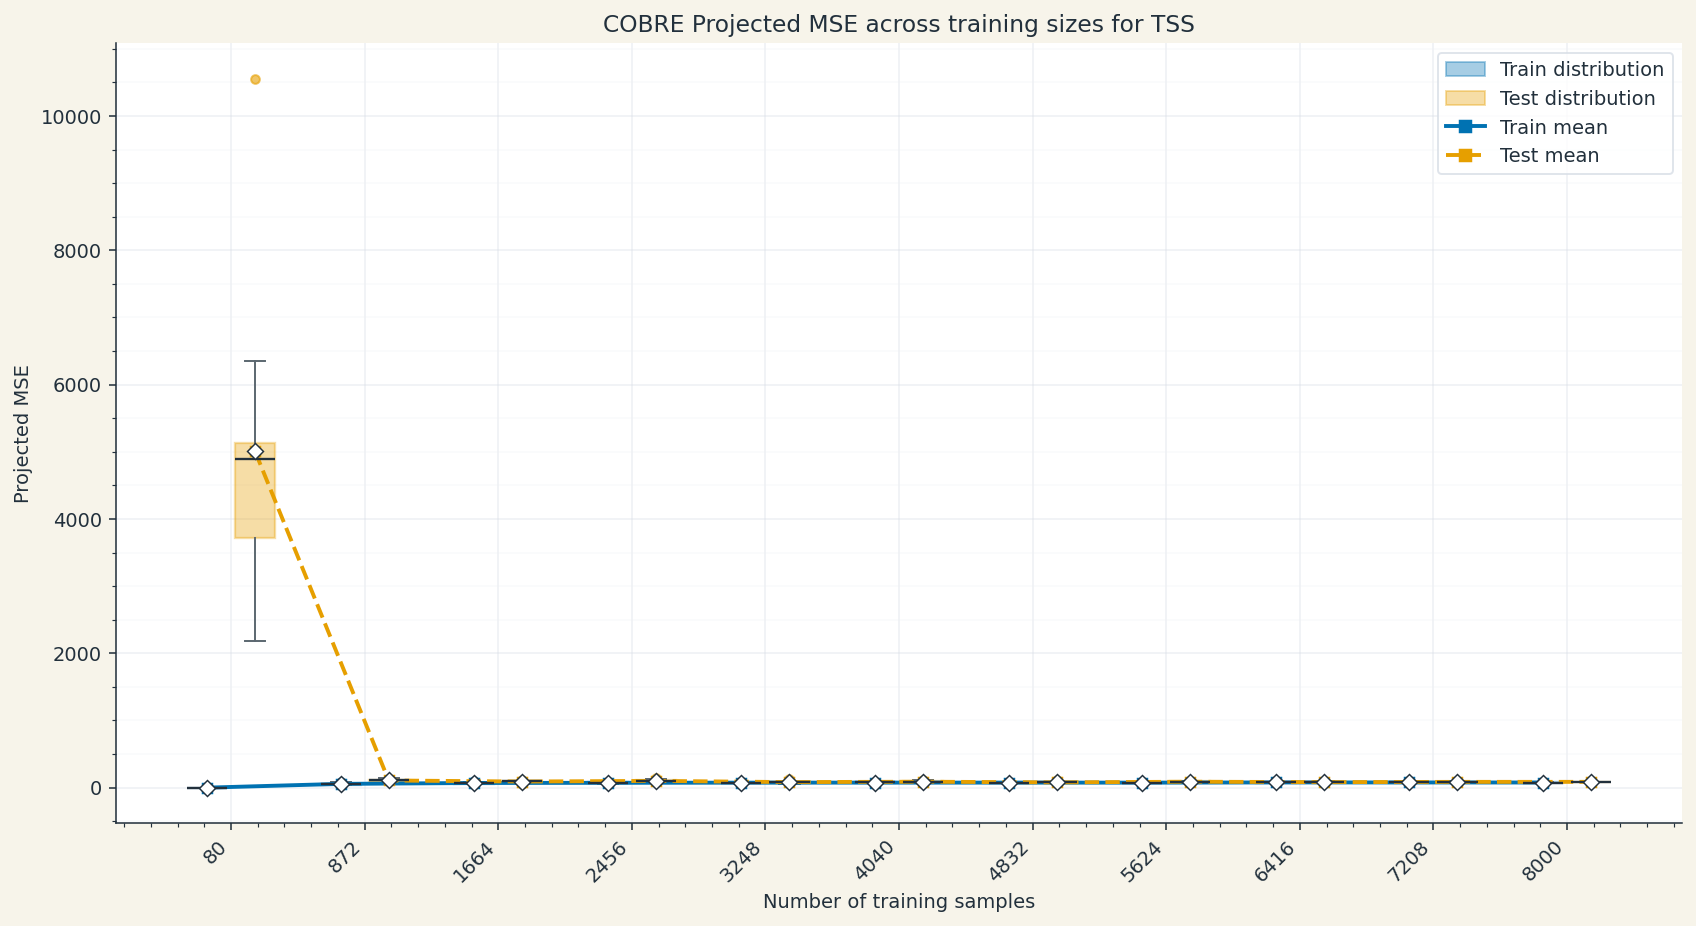

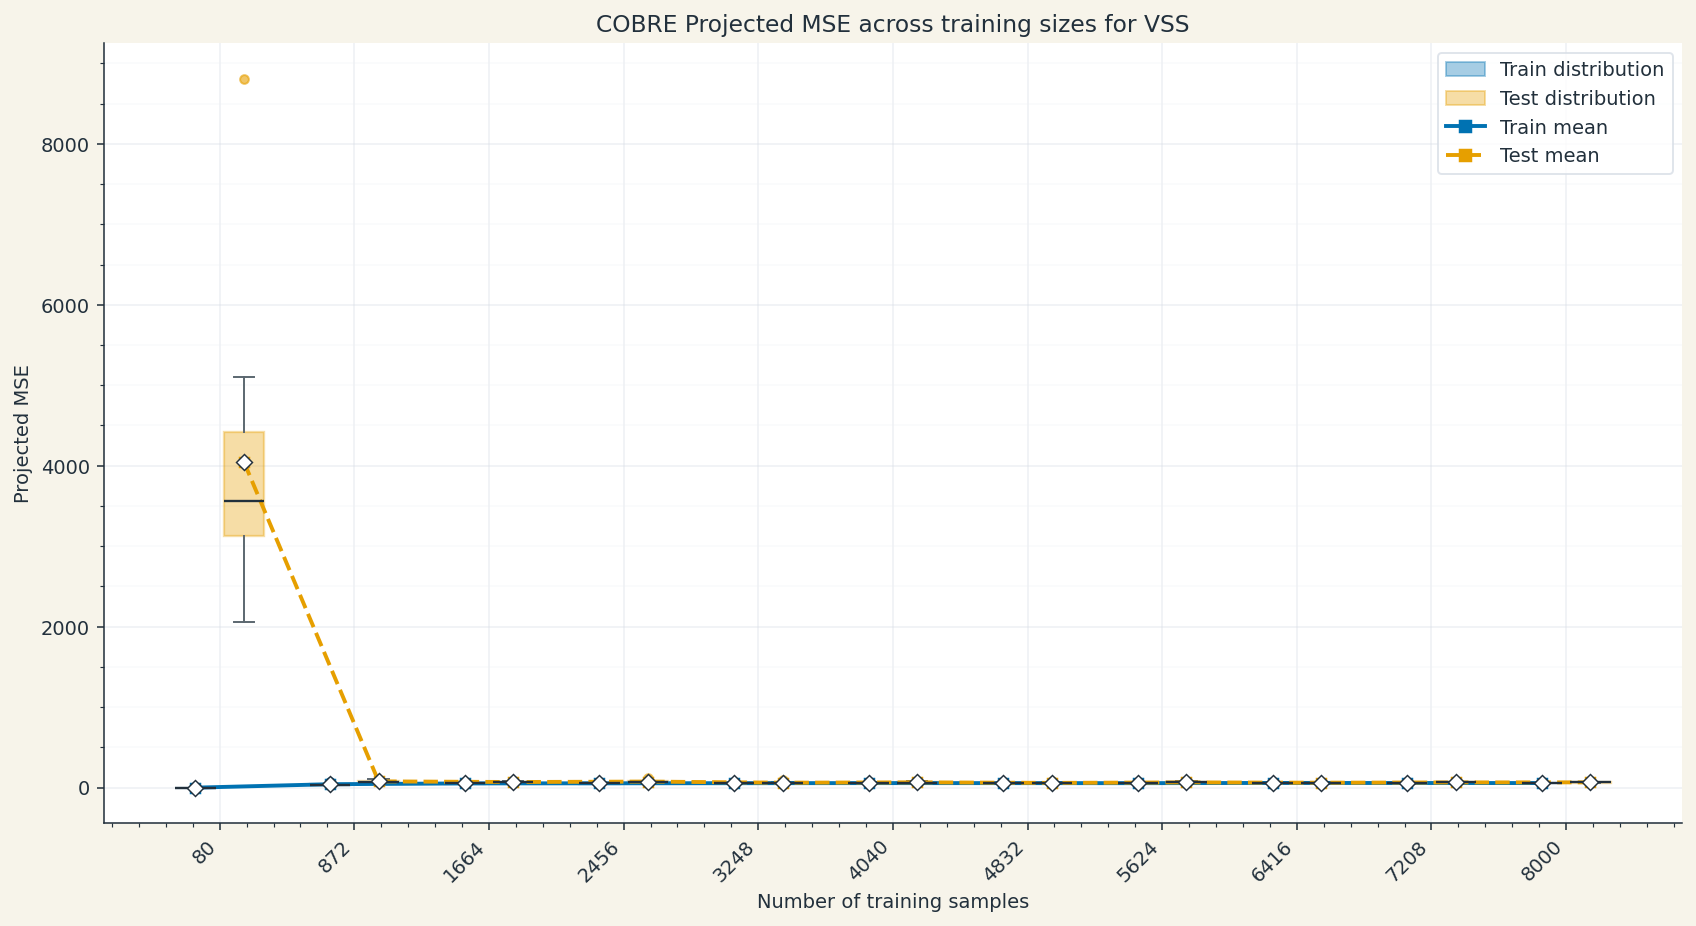

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_cobre_params, run_cobre_pipeline
from src.utils.analysis import describe_and_display_table, run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

if "analysis_metric" not in globals():
    raise NameError(
        "Run the first notebook cell before the analysis section so analysis_metric is defined."
    )
analysis_metric = str(globals()["analysis_metric"])
analysis_overrides = dict(globals().get("analysis_overrides", {}))

cobre_analysis_params = load_cobre_params()
cobre_previous_result = globals().get("cobre_result")
cobre_analysis_hyperparameters = (
    dict(cobre_previous_result["best_hyperparameters"] )
    if cobre_previous_result is not None
    else dict(cobre_analysis_params["training_defaults"] )
    )

cobre_analysis_result = run_model_dataset_size_analysis(
    "cobre",
    cobre_dataset,
    cobre_A_matrix,
    run_cobre_pipeline,
    model_params=cobre_analysis_params,
    model_hyperparameters=cobre_analysis_hyperparameters,
    persist_artifacts=False,
    extra_runner_kwargs={"composition_matrix": composition_matrix},
    **analysis_overrides,
    )

if analysis_metric not in cobre_analysis_result["per_target_metrics"].columns:
    available_metrics = [
        column
        for column in cobre_analysis_result["per_target_metrics"].columns
        if column.startswith(("projected_", "raw_"))
        ]
    raise KeyError(
        f"Requested metric '{analysis_metric}' is unavailable for COBRE analysis. "
        f"Available metrics: {', '.join(sorted(available_metrics))}."
        )

print("COBRE analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(cobre_analysis_result['prediction_tables'])}")
describe_and_display_table(
    "COBRE analysis configuration",
    "This table lists the dataset-size sweep configuration used to evaluate COBRE under repeated train-test resampling.",
    pd.DataFrame([cobre_analysis_result["analysis_config"]]),
    )
describe_and_display_table(
    "COBRE analysis run metadata preview",
    "This table previews the run-level metadata for the COBRE analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.",
    cobre_analysis_result["run_metadata"].head(),
    )

for target_name in cobre_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        cobre_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="COBRE",
        )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_xgboost_regressor_params, run_xgboost_regressor_pipeline
from src.utils.analysis import describe_and_display_table, run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

if "analysis_metric" not in globals():
    raise NameError(
        "Run the first notebook cell before the analysis section so analysis_metric is defined."
    )
analysis_metric = str(globals()["analysis_metric"])
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

xgboost_analysis_params = load_xgboost_regressor_params()
xgboost_previous_result = classical_results.get("xgboost_regressor")
xgboost_analysis_hyperparameters = (
    dict(xgboost_previous_result["best_hyperparameters"] )
    if xgboost_previous_result is not None
    else dict(xgboost_analysis_params["training_defaults"] )
)

xgboost_analysis_result = run_model_dataset_size_analysis(
    "xgboost_regressor",
    classical_benchmark_dataset,
    A_matrix,
    run_xgboost_regressor_pipeline,
    model_params=xgboost_analysis_params,
    model_hyperparameters=xgboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
)

if analysis_metric not in xgboost_analysis_result["per_target_metrics"].columns:
    available_metrics = [
        column
        for column in xgboost_analysis_result["per_target_metrics"].columns
        if column.startswith(("projected_", "raw_"))
        ]
    raise KeyError(
        f"Requested metric '{analysis_metric}' is unavailable for XGBoost analysis. "
        f"Available metrics: {', '.join(sorted(available_metrics))}."
    )

print("XGBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(xgboost_analysis_result['prediction_tables'])}")
describe_and_display_table(
    "XGBoost analysis configuration",
    "This table lists the dataset-size sweep configuration used to evaluate the XGBoost regressor under the shared COBRE-aligned benchmark contract.",
    pd.DataFrame([xgboost_analysis_result["analysis_config"]]),
)
describe_and_display_table(
    "XGBoost analysis run metadata preview",
    "This table previews the run-level metadata for the XGBoost analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.",
    xgboost_analysis_result["run_metadata"].head(),
)

for target_name in classical_benchmark_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        xgboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="XGBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_lightgbm_regressor_params, run_lightgbm_regressor_pipeline
from src.utils.analysis import describe_and_display_table, run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

if "analysis_metric" not in globals():
    raise NameError(
        "Run the first notebook cell before the analysis section so analysis_metric is defined."
    )
analysis_metric = str(globals()["analysis_metric"])
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

lightgbm_analysis_params = load_lightgbm_regressor_params()
lightgbm_previous_result = classical_results.get("lightgbm_regressor")
lightgbm_analysis_hyperparameters = (
    dict(lightgbm_previous_result["best_hyperparameters"] )
    if lightgbm_previous_result is not None
    else dict(lightgbm_analysis_params["training_defaults"] )
)

lightgbm_analysis_result = run_model_dataset_size_analysis(
    "lightgbm_regressor",
    classical_benchmark_dataset,
    A_matrix,
    run_lightgbm_regressor_pipeline,
    model_params=lightgbm_analysis_params,
    model_hyperparameters=lightgbm_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
)

if analysis_metric not in lightgbm_analysis_result["per_target_metrics"].columns:
    available_metrics = [
        column
        for column in lightgbm_analysis_result["per_target_metrics"].columns
        if column.startswith(("projected_", "raw_"))
        ]
    raise KeyError(
        f"Requested metric '{analysis_metric}' is unavailable for LightGBM analysis. "
        f"Available metrics: {', '.join(sorted(available_metrics))}."
    )

print("LightGBM analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(lightgbm_analysis_result['prediction_tables'])}")
describe_and_display_table(
    "LightGBM analysis configuration",
    "This table lists the dataset-size sweep configuration used to evaluate the LightGBM regressor under the shared COBRE-aligned benchmark contract.",
    pd.DataFrame([lightgbm_analysis_result["analysis_config"]]),
)
describe_and_display_table(
    "LightGBM analysis run metadata preview",
    "This table previews the run-level metadata for the LightGBM analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.",
    lightgbm_analysis_result["run_metadata"].head(),
)

for target_name in classical_benchmark_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        lightgbm_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="LightGBM Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_catboost_regressor_params, run_catboost_regressor_pipeline
from src.utils.analysis import describe_and_display_table, run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

if "analysis_metric" not in globals():
    raise NameError(
        "Run the first notebook cell before the analysis section so analysis_metric is defined."
    )
analysis_metric = str(globals()["analysis_metric"])
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

catboost_analysis_params = load_catboost_regressor_params()
catboost_previous_result = classical_results.get("catboost_regressor")
catboost_analysis_hyperparameters = (
    dict(catboost_previous_result["best_hyperparameters"] )
    if catboost_previous_result is not None
    else dict(catboost_analysis_params["training_defaults"] )
)

catboost_analysis_result = run_model_dataset_size_analysis(
    "catboost_regressor",
    classical_benchmark_dataset,
    A_matrix,
    run_catboost_regressor_pipeline,
    model_params=catboost_analysis_params,
    model_hyperparameters=catboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
)

if analysis_metric not in catboost_analysis_result["per_target_metrics"].columns:
    available_metrics = [
        column
        for column in catboost_analysis_result["per_target_metrics"].columns
        if column.startswith(("projected_", "raw_"))
        ]
    raise KeyError(
        f"Requested metric '{analysis_metric}' is unavailable for CatBoost analysis. "
        f"Available metrics: {', '.join(sorted(available_metrics))}."
    )

print("CatBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(catboost_analysis_result['prediction_tables'])}")
describe_and_display_table(
    "CatBoost analysis configuration",
    "This table lists the dataset-size sweep configuration used to evaluate the CatBoost regressor under the shared COBRE-aligned benchmark contract.",
    pd.DataFrame([catboost_analysis_result["analysis_config"]]),
)
describe_and_display_table(
    "CatBoost analysis run metadata preview",
    "This table previews the run-level metadata for the CatBoost analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.",
    catboost_analysis_result["run_metadata"].head(),
)

for target_name in classical_benchmark_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        catboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="CatBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_adaboost_regressor_params, run_adaboost_regressor_pipeline
from src.utils.analysis import describe_and_display_table, run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

if "analysis_metric" not in globals():
    raise NameError(
        "Run the first notebook cell before the analysis section so analysis_metric is defined."
    )
analysis_metric = str(globals()["analysis_metric"])
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

adaboost_analysis_params = load_adaboost_regressor_params()
adaboost_previous_result = classical_results.get("adaboost_regressor")
adaboost_analysis_hyperparameters = (
    dict(adaboost_previous_result["best_hyperparameters"] )
    if adaboost_previous_result is not None
    else dict(adaboost_analysis_params["training_defaults"] )
)

adaboost_analysis_result = run_model_dataset_size_analysis(
    "adaboost_regressor",
    classical_benchmark_dataset,
    A_matrix,
    run_adaboost_regressor_pipeline,
    model_params=adaboost_analysis_params,
    model_hyperparameters=adaboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
)

if analysis_metric not in adaboost_analysis_result["per_target_metrics"].columns:
    available_metrics = [
        column
        for column in adaboost_analysis_result["per_target_metrics"].columns
        if column.startswith(("projected_", "raw_"))
        ]
    raise KeyError(
        f"Requested metric '{analysis_metric}' is unavailable for AdaBoost analysis. "
        f"Available metrics: {', '.join(sorted(available_metrics))}."
    )

print("AdaBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(adaboost_analysis_result['prediction_tables'])}")
describe_and_display_table(
    "AdaBoost analysis configuration",
    "This table lists the dataset-size sweep configuration used to evaluate the AdaBoost regressor under the shared COBRE-aligned benchmark contract.",
    pd.DataFrame([adaboost_analysis_result["analysis_config"]]),
)
describe_and_display_table(
    "AdaBoost analysis run metadata preview",
    "This table previews the run-level metadata for the AdaBoost analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.",
    adaboost_analysis_result["run_metadata"].head(),
)

for target_name in classical_benchmark_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        adaboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="AdaBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_random_forest_regressor_params, run_random_forest_regressor_pipeline
from src.utils.analysis import describe_and_display_table, run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

if "analysis_metric" not in globals():
    raise NameError(
        "Run the first notebook cell before the analysis section so analysis_metric is defined."
    )
analysis_metric = str(globals()["analysis_metric"])
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

random_forest_analysis_params = load_random_forest_regressor_params()
random_forest_previous_result = classical_results.get("random_forest_regressor")
random_forest_analysis_hyperparameters = (
    dict(random_forest_previous_result["best_hyperparameters"] )
    if random_forest_previous_result is not None
    else dict(random_forest_analysis_params["training_defaults"] )
)

random_forest_analysis_result = run_model_dataset_size_analysis(
    "random_forest_regressor",
    classical_benchmark_dataset,
    A_matrix,
    run_random_forest_regressor_pipeline,
    model_params=random_forest_analysis_params,
    model_hyperparameters=random_forest_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
)

if analysis_metric not in random_forest_analysis_result["per_target_metrics"].columns:
    available_metrics = [
        column
        for column in random_forest_analysis_result["per_target_metrics"].columns
        if column.startswith(("projected_", "raw_"))
        ]
    raise KeyError(
        f"Requested metric '{analysis_metric}' is unavailable for Random forest analysis. "
        f"Available metrics: {', '.join(sorted(available_metrics))}."
    )

print("Random forest analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(random_forest_analysis_result['prediction_tables'])}")
describe_and_display_table(
    "Random forest analysis configuration",
    "This table lists the dataset-size sweep configuration used to evaluate the random forest regressor under the shared COBRE-aligned benchmark contract.",
    pd.DataFrame([random_forest_analysis_result["analysis_config"]]),
)
describe_and_display_table(
    "Random forest analysis run metadata preview",
    "This table previews the run-level metadata for the random forest analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.",
    random_forest_analysis_result["run_metadata"].head(),
)

for target_name in classical_benchmark_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        random_forest_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="Random Forest Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_svr_regressor_params, run_svr_regressor_pipeline
from src.utils.analysis import describe_and_display_table, run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

if "analysis_metric" not in globals():
    raise NameError(
        "Run the first notebook cell before the analysis section so analysis_metric is defined."
    )
analysis_metric = str(globals()["analysis_metric"])
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

svr_analysis_params = load_svr_regressor_params()
svr_previous_result = classical_results.get("svr_regressor")
svr_analysis_hyperparameters = (
    dict(svr_previous_result["best_hyperparameters"] )
    if svr_previous_result is not None
    else dict(svr_analysis_params["training_defaults"] )
)

svr_analysis_result = run_model_dataset_size_analysis(
    "svr_regressor",
    classical_benchmark_dataset,
    A_matrix,
    run_svr_regressor_pipeline,
    model_params=svr_analysis_params,
    model_hyperparameters=svr_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
)

if analysis_metric not in svr_analysis_result["per_target_metrics"].columns:
    available_metrics = [
        column
        for column in svr_analysis_result["per_target_metrics"].columns
        if column.startswith(("projected_", "raw_"))
        ]
    raise KeyError(
        f"Requested metric '{analysis_metric}' is unavailable for SVR analysis. "
        f"Available metrics: {', '.join(sorted(available_metrics))}."
    )

print("SVR analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(svr_analysis_result['prediction_tables'])}")
describe_and_display_table(
    "SVR analysis configuration",
    "This table lists the dataset-size sweep configuration used to evaluate the SVR regressor under the shared COBRE-aligned benchmark contract.",
    pd.DataFrame([svr_analysis_result["analysis_config"]]),
)
describe_and_display_table(
    "SVR analysis run metadata preview",
    "This table previews the run-level metadata for the SVR analysis sweep, including the sampled dataset size, repeat index, train size, test size, and run seed.",
    svr_analysis_result["run_metadata"].head(),
)

for target_name in classical_benchmark_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        svr_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="SVR Regressor",
    )
    display(figure)
    plt.close(figure)